
# **Türkiye Ulusal Gözlemevleri Bünyesindeki Erzurum DAG Yerleşkesi ve Antalya TUG Yerleşkesi için Gece Işıklarının Analizi**

## **Eğitim ve Uygulama Serisi - Bölüm 5: VIIRS NTL Verilerinden Zaman Serisi Analizleri**

- Bu eğitim serisi, **TÜBİTAK** 3501 Kariyer Geliştirme Programı kapsamında desteklenen **"124F297"** numaralı proje çerçevesinde geliştirilmiştir.

- **Dokümanı Hazırlayanlar: Dr. Kazım Kaba, Dr. Funda Aksoy, Doç. Dr. İlham Nasıroğlu, Fethullah Polat, Sima Aydın, Rabia Beyza Türkmen, Yusuf Sağlam, Prof. Dr. Cahit Yeşilyaprak, Prof. Dr. H. Mustafa Kandırmaz**

- Bu dördüncü uygulama dosyasında; Türkiye, Antalya ve Erzurum bölgeleri ile Türkiye Ulusal Gözlemevleri yerleşkeleri (TUG ve DAG) üzerindeki yapay ışık kirliliğinin 14 yıllık (2012–2025) uzun dönemli zamansal eğilimlerini incelemek amacıyla **Zaman Serisi Analizleri (Time Series Analysis - TSA)** gerçekleştireceğiz.

- Bu doğrultuda; kar örtüsü ve uydu görüş açısı kısıtlarından arındırılmış en kararlı katman olan **"NearNadir_Composite_Snow_Free"** verilerini kullanarak, mutlak radyans değerleri üzerinden hem aylık (yüksek frekanslı mevsimsel salınımlar) hem de yıllık (uzun vadeli kentsel büyüme) bazda doğrusal eğilim modellerini (OLS Regresyon, Mann-Kendall Trend Testi ve Sen's Slope Tahmincisi) çalıştıracağız.



## **5.1 VIIRS NTL Kompozit Verilerinin İşlenmesi**

- Önceki (ikinci) bölümde açıklandığı üzere verilerin yerel diske indirilmesinden sonraki aşama, bu veri setlerinin hazırlanmasıdır.

- VIIRS NTL VNP46A* ürünleri son kullanıcıya yönelik Seviye-3 (Level 3) veri setleri olmaları sayesinde doğrudan analize elverişli bir yapı sunmaktadır.

- HDF5 formatında sunulan bu ürünler, yaklaşık 15 ark-saniye (~500 metre) konumsal çözünürlükte coğrafi grid yapısına sahiptir.

- Veriler 10X10 derecelik gridler şeklinde sunulduğu için Türkiye çalışma alanını toplam altı grid kapsamaktadır. Bu altı grid mozaikleme (mosaicing) yöntemiyle birleştirildiğinde, 30°–50° Kuzey enlemleri ile 20°–50° Doğu boylamları arasındaki coğrafi alan tam olarak kapsanmaktadır.

- Yalnızca kara alanlarındaki NTL değerleri üzerine odaklanıldığı için, idari sınır vektör verileri kullanılarak Antalya, Erzurum ve Türkiye geneli için kırpma (clipping/cropping) işlemleri gerçekleştirilmekte ve dosyalar daha sonra kullanılmak üzere arşivlenmektedir.



## **5.1.1 VNP46A4 Yıllık Verilerinin İşlenmesi**

- Eğitim serimizin bu bölümünde, yıllık kompozit ürün olan VNP46A4 dosyalarının Python ortamında rioxarray kütüphanesi kullanılarak nasıl işleneceğini inceleyeceğiz.

- Aşağıdaki kod blokları, projenin eğitim hedeflerine uygun olarak AllAngle (Tüm Açılar), NearNadir (Nadire Yakın Açılar) ve OffNadir (Nadir Dışı Açılar) olmak üzere 3 farklı uydu/sensör bakış açısı kategorisini ve her bir açı için üretilen karlı (Snow_Covered) ile karsız (Snow_Free) durumdaki toplam 6 katmanı kapsayacak şekilde yapılandırılmıştır.

- İlk olarak, veri işleme süreçlerinde ve coğrafi okumalarda kullanacağımız Python kütüphanelerini çalışma ortamımıza dahil ediyoruz.

- Tanımlanan fonksiyonlar; yerel diskteki ilgili HDF5 dosyalarını tarayıp bulacak; AllAngle, NearNadir ve OffNadir bakış açılarında karlı ve karsız şartlar için hesaplanan altı NTL gridini coğrafi olarak mozaikleyip (birleştirip) GeoTIFF dosya formatında yerel diske arşivleyecektir.


In [1]:

# Gerekli modülleri içe aktarıyoruz
import os
import glob
import numpy as np
import rioxarray as rxr
from rioxarray import merge
import warnings
# Uyarı mesajlarını kapatıyoruz
warnings.filterwarnings('ignore')

def hedefDosyaBul(kaynak_dizin, yil_no):
    """
    Belirtilen kaynak dizin içerisinde, aranan yıla ait tüm 
    HDF5 (.h5) formatındaki VIIRS NTL dosyalarını bulur ve liste olarak döndürür.
    """
    # Dosya adı örüntüsüne göre eşleştirme yapıyoruz (Örn: ...A2012*.h5)
    h5_dosyalar = glob.glob(os.path.join(kaynak_dizin, f'*A{yil_no}*.h5'))
    return h5_dosyalar

def h5DosyaIsle(gridler, hedef_dizin):
    """
    Hedef yıla ait 6 farklı coğrafi grid hücresini okur;
    AllAngle, NearNadir ve OffNadir bakış açılarında karlı ve karsız olmak üzere
    toplam 6 farklı veri katmanını mozaikleyerek (birleştirerek) kaydeder.
    """
    # VNP46A4 HDF5 dosya yapısı içerisindeki 6 adet veri katmanının isim tanımlamaları
    katmanlar = {
        'AllAngle_SC': 'HDFEOS_GRIDS_VIIRS_Grid_DNB_2d_Data_Fields_AllAngle_Composite_Snow_Covered',
        'AllAngle_SF': 'HDFEOS_GRIDS_VIIRS_Grid_DNB_2d_Data_Fields_AllAngle_Composite_Snow_Free',
        'NearNadir_SC': 'HDFEOS_GRIDS_VIIRS_Grid_DNB_2d_Data_Fields_NearNadir_Composite_Snow_Covered',
        'NearNadir_SF': 'HDFEOS_GRIDS_VIIRS_Grid_DNB_2d_Data_Fields_NearNadir_Composite_Snow_Free',
        'OffNadir_SC': 'HDFEOS_GRIDS_VIIRS_Grid_DNB_2d_Data_Fields_OffNadir_Composite_Snow_Covered',
        'OffNadir_SF': 'HDFEOS_GRIDS_VIIRS_Grid_DNB_2d_Data_Fields_OffNadir_Composite_Snow_Free'
    }
    
    # Her bir katmana ait 6 coğrafi grid hücresini geçici olarak tutacak listeleri oluşturuyoruz
    grid_listeleri = {k: [] for k in katmanlar.keys()}
    
    # Bölgedeki tüm coğrafi grid hücrelerini (h20v04, h21v04 vb.) tek tek döngüye alıyoruz
    for grid in gridler:
        print('-'*80)
        print(f"Okunuyor: {os.path.basename(grid)}")
        
        # rioxarray yardımıyla HDF5 dosyasını coğrafi referanslı olarak açıyoruz
        viirs_ntl = rxr.open_rasterio(grid)
        
        # Koordinat eksen isimlerini standartlaştırıyoruz
        viirs_ntl = viirs_ntl.rename({'x': 'longitude', 'y': 'latitude'})
        
        # İlgili grid dosyasındaki 6 katmanı sırasıyla okuyup listelerine ekliyoruz
        for k, katman_yolu in katmanlar.items():
            grid_listeleri[k].append(viirs_ntl[katman_yolu])
            
    # Her bir katman için toplanan gridleri birleştirerek tek bir Türkiye matrisi oluşturuyoruz
    mozaikler = {}
    print("\nMozaikleme (Birleştirme) işlemi başlatıldı...")
    for k, liste in grid_listeleri.items():
        # Geçersiz/boş pikselleri standartlaştırmak için nodata değerini -999.9 yapıyoruz
        mozaikler[k] = merge.merge_arrays(liste, nodata=-999.9)
    
    # Çıktı dosya isimleri için baz ismi alıyoruz (Örn: VNP46A4.A2012001)
    girdi_ismi = os.path.basename(grid).split('.')
    dosya_on_eki = '.'.join(girdi_ismi[:2])
    
    # Oluşturulan 6 adet mozaik matrisi sırasıyla GeoTIFF formatında diske yazıyoruz
    for k, mozaik_veri in mozaikler.items():
        cikti_dosya_adi = f"{dosya_on_eki}.{katmanlar[k]}.tif"
        cikti_tam_yol = os.path.join(hedef_dizin, cikti_dosya_adi)
        
        # rio.to_raster() fonksiyonu koordinat sistemi ve projeksiyonu koruyarak kaydeder
        mozaik_veri.rio.to_raster(cikti_tam_yol)
        print(f"Kaydedildi -> {cikti_dosya_adi}")
        
    return mozaikler

# Yukarıda tanımlanan fonksiyonları veri dizinlerimiz üzerinde döngüye sokarak çalıştırıyoruz.

# Yerel bilgisayarınızdaki kaynak ve hedef klasör yollarını tanımlayınız
kaynakDizin = 'E:\\=PROJELER\\=TUBITAK_3501_2024\\veri\\uydu\\viirs_ntl\\h5Files\\VNP46A4'
hedefDizin = 'E:\\=PROJELER\\=TUBITAK_3501_2024\\veri\\uydu\\viirs_ntl\\TifFiles\\_temp'
# Birleştirilen dosyalar Türkiye, Antalya ve Erzurum alanları çıkarıldıktan sonra silinecek

# Proje kapsamındaki analiz yıllarının aralığını belirliyoruz
ilk_yil = 2012
son_yil = 2025

# Belirlenen yıllar arasında sırasıyla veri işleme döngüsünü başlatıyoruz
for yil in range(ilk_yil, son_yil + 1): # Son yılı da dahil etmek için +1 eklenmiştir
    print('%'*80)
    # İlgili yıla ait grid dosyalarını buluyoruz
    gridler = hedefDosyaBul(kaynakDizin, yil)
    
    if len(gridler) != 0:
        print(f"{yil} yılına ait {len(gridler)} adet dosya işleniyor... ")
        # Mozaikleme ve kaydetme fonksiyonunu çağırıyoruz
        mozaikler = h5DosyaIsle(gridler, hedefDizin)
    else:
        print(f"{yil} yılına ait kaynak dosya bulunamadı!")
        continue

print('!'*100)
print("Tüm yıllara ait VNP46A4 dosyalarının işleme ve GeoTIFF dönüştürme süreçleri başarıyla tamamlanmıştır.")


%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
2012 yılına ait 6 adet dosya işleniyor... 
--------------------------------------------------------------------------------
Okunuyor: VNP46A4.A2012001.h20v04.002.2025086172552.h5
--------------------------------------------------------------------------------
Okunuyor: VNP46A4.A2012001.h20v05.002.2025086172407.h5
--------------------------------------------------------------------------------
Okunuyor: VNP46A4.A2012001.h21v04.002.2025086172945.h5
--------------------------------------------------------------------------------
Okunuyor: VNP46A4.A2012001.h21v05.002.2025086172811.h5
--------------------------------------------------------------------------------
Okunuyor: VNP46A4.A2012001.h22v04.002.2025086172457.h5
--------------------------------------------------------------------------------
Okunuyor: VNP46A4.A2012001.h22v05.002.2025086171546.h5

Mozaikleme (Birleştirme) işlemi başlatıldı...
Kaydedildi ->


## **5.1.2 VNP46A4 GeoTiff Dosyalarının Kesilmesi (Maskelenmesi)**

- Yukarıdaki adımlarla Türkiye'nin yakın çevresini de kapsayan yıllık mozaik NTL verileri üretilmiştir. Ancak analizlerimizde yalnızca Türkiye ulusal kara sınırları ile ilgilendiğimiz için, GADM (Database of Global Administrative Areas, Sürüm 4.1; https://gadm.org/download_country.html) veri tabanından elde edilen ülke sınır vektör dosyası (Shapefile) kullanılarak alt alanlar oluşturulacaktır.

- Bu süreci otomatikleştirecek ve toplu maskeleme yapacak olan kesme fonksiyonu, alt hücrede tanımlanmıştır.


In [2]:

# Gerekli modülleri içe aktarıyoruz
import os
import glob
import subprocess

def geotifDosyaKes(kaynakKlasor, hedefKlasor, vektorDosya, shpIsmi, alanIsmi):
    """
    Belirtilen kaynak klasördeki GeoTIFF dosyalarını, verilen bir vektör sınır
    dosyasına (Shapefile) göre keserek (crop/mask) hedef klasöre kaydeder.
    """
    
    # tif ile biten dosyaları otomatik olarak filtreleyip listeliyoruz.
    tif_dosyalar = glob.glob(kaynakKlasor + '\\*.tif')
    
    print('='*80)
    print(f"{len(tif_dosyalar)} adet GeoTIFF dosyası kesme işlemi için tespit edildi.")
    
    # Bulunan tüm GeoTIFF dosyalarını sırasıyla döngüye alıyoruz
    for girdi_tif_dosya in tif_dosyalar:
        
        # Girdi dosyasının ismini parçalayarak çıktı dosyasının ismini oluşturuyoruz
        # Örn: VNP46A4.A2012001.katman_ismi.tif -> [VNP46A4, A2012001, katman_ismi, tif]
        girdi_tif_ismi = os.path.basename(girdi_tif_dosya).split('.')
        
        # Çıktı ismine kesilen bölgenin/alanın adını (Örn: Erzurum veya Antalya) ekliyoruz
        cikti_tif_ismi = hedefKlasor + '\\' + '.'.join(girdi_tif_ismi[0:3]) + '.' + alanIsmi + '.tif'
        
        # GDAL gdalwarp komutunu komut satırı parametreleriyle oluşturuyoruz:
        # -overwrite         : Hedef klasörde aynı isimde dosya varsa üzerine yazar.
        # -of GTiff          : Çıktı dosya formatını GeoTIFF olarak belirler.
        # -cutline           : Kesme işlemi için kullanılacak vektör sınır dosyasını (Shapefile) tanımlar.
        # -cl                : Shapefile içerisindeki katman (layer) adını belirtir (gadm41_TUR_1 vb.).
        # -crop_to_cutline   : Görüntüyü vektörün en dış sınır kutusuna (bounding box) göre kırpar.
        komut = (
            "gdalwarp -overwrite -of GTiff -cutline " + vektorDosya + 
            " -cl gadm41_" + shpIsmi + 
            " -crop_to_cutline " + girdi_tif_dosya + " " + cikti_tif_ismi
        )
        
        # Oluşturulan gdalwarp komutunu işletim sistemi terminalinde çalıştırıyoruz
        subprocess.call(komut)
        
    print('%'*80)
    print("Maskeleme ve kırpma işlemleri başarıyla tamamlandı.")

# İşlenecek GeoTIFF dosyalarının bulunduğu klasör yolu
kaynak_klasor = 'E:\\=PROJELER\\=TUBITAK_3501_2024\\veri\\uydu\\viirs_ntl\\TifFiles\\_temp'

# Kesilen yeni dosyaların kaydedileceği hedef klasör yolu
hedef_klasor = 'E:\\=PROJELER\\=TUBITAK_3501_2024\\veri\\uydu\\viirs_ntl\\TifFiles\\VNP46A4'



- **Antalya Bölgesi Maskelemesi:** Öncelikle Antalya bölgesi için NTL verilerinin coğrafi sınırlandırmasını yapacağız. Bu işlem için sırasıyla; ilk olarak fonksiyon tanımlarının yer aldığı üst hücrenin çalıştırılması ve ardından Antalya il sınır vektör dosyasını çağıran alttaki hücrenin işletilmesi gerekmektedir.


In [2]:

# Antalya il sınırına ait vektör sınır dosyasının (Shapefile) bilgisayardaki tam yolu tanımlanıyor
vektor_dosya_ant = 'E:\\=PROJELER\\=TUBITAK_3501_2024\\veri\\vektor\\gadm41_ANT_shp\\gadm41_ANT.shp'
# Geliştirdiğimiz geotifDosyaKes fonksiyonunu Antalya sınırları için çalıştırıyoruz
geotifDosyaKes(kaynak_klasor, hedef_klasor, vektor_dosya_ant, 'ANT', 'Antalya')


84 adet GeoTIFF dosyası kesme işlemi için tespit edildi.
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
Maskeleme ve kırpma işlemleri başarıyla tamamlandı.



- **Erzurum Bölgesi Maskelemesi:** Şimdi aynı süreci Erzurum bölgesi için uygulayacağız. (Not: Jupyter çekirdeği/Kernel yeniden başlatıldıysa, restart işlem sırasına göre önce üstteki fonksiyon tanımı hücresinin yeniden çalıştırılması, ardından Erzurum'a özel vektör yollarını içeren alt kesme hücresinin çalıştırılması gerekmektedir.)


In [3]:

# Erzurum il sınırına ait vektör sınır dosyasının (Shapefile) bilgisayardaki tam yolu tanımlanıyor
vektor_dosya_erz = 'E:\\=PROJELER\\=TUBITAK_3501_2024\\veri\\vektor\\gadm41_ERZ_shp\\gadm41_ERZ.shp'
# Geliştirdiğimiz geotifDosyaKes fonksiyonunu Erzurum sınırları için çalıştırıyoruz
geotifDosyaKes(kaynak_klasor, hedef_klasor, vektor_dosya_erz, 'ERZ', 'Erzurum')


84 adet GeoTIFF dosyası kesme işlemi için tespit edildi.
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
Maskeleme ve kırpma işlemleri başarıyla tamamlandı.



- **Türkiye Geneli Maskelemesi:** Son olarak Türkiye geneli için NTL verilerinin coğrafi maskeleme adımını gerçekleştireceğiz. Yine sırasıyla önce fonksiyon tanım hücresinin (gerekirse Kernel Restart sonrası) ve ardından Türkiye ulusal sınır Shapefile dosyasını (gadm41_TUR_0.shp) kullanan alttaki maskeleme hücresinin çalıştırılması gerekmektedir.


In [3]:
# Türkiye sınırına ait vektör sınır dosyasının (Shapefile) bilgisayardaki tam yolu tanımlanıyor
vektor_dosya_tur = 'E:\\=PROJELER\\=TUBITAK_3501_2024\\veri\\vektor\\gadm41_TUR_shp\\gadm41_TUR_0.shp'
# Geliştirdiğimiz geotifDosyaKes fonksiyonunu Türkiye sınırları için çalıştırıyoruz
geotifDosyaKes(kaynak_klasor, hedef_klasor, vektor_dosya_tur, 'TUR_0', 'Turkiye')


84 adet GeoTIFF dosyası kesme işlemi için tespit edildi.
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
Maskeleme ve kırpma işlemleri başarıyla tamamlandı.



## **5.1.3 VNP46A3 Aylık Verilerinin İşlenmesi**

- Yıllık değişimlerin yanı sıra projemizde mevsimsel ve aylık ışık kirliliği dinamiklerini yakalayabilmek için aylık kompozit veri ürünü olan VNP46A3 dosyalarını da işlememiz gerekmektedir.

- VNP46A3 verilerinin işlenme adımları, yıllık (VNP46A4) verilerle büyük oranda paralellik göstermekle birlikte; verilerin aylık periyotları ifade eden Jülyen gün kodlarına (Julian Day) göre döngüye alınması ve her ayın ilk gününe denk gelen takvimin otomatik hesaplanması bakımından farklılık göstermektedir.


In [1]:

# Gerekli modülleri içe aktarıyoruz
import os
import glob
import numpy as np
import rioxarray as rxr
from rioxarray import merge
import warnings
# Uyarıları gizliyoruz
warnings.filterwarnings('ignore')

def h5DosyaIsle(gridler, hedef_dizin):
    """
    Belirli bir aya ait 6 adet coğrafi grid hücelerini (h20v04, h21v05 vb.) okur;
    AllAngle, NearNadir ve OffNadir bakış açılarında karlı ve karsız olmak üzere
    toplam 6 farklı veri katmanını mozaikleyerek (birleştirerek) kaydeder.
    """
    # VNP46A3 HDF5 dosyası içindeki 6 adet veri katmanının adları
    katmanlar = {
        'AllAngle_SC': 'HDFEOS_GRIDS_VIIRS_Grid_DNB_2d_Data_Fields_AllAngle_Composite_Snow_Covered',
        'AllAngle_SF': 'HDFEOS_GRIDS_VIIRS_Grid_DNB_2d_Data_Fields_AllAngle_Composite_Snow_Free',
        'NearNadir_SC': 'HDFEOS_GRIDS_VIIRS_Grid_DNB_2d_Data_Fields_NearNadir_Composite_Snow_Covered',
        'NearNadir_SF': 'HDFEOS_GRIDS_VIIRS_Grid_DNB_2d_Data_Fields_NearNadir_Composite_Snow_Free',
        'OffNadir_SC': 'HDFEOS_GRIDS_VIIRS_Grid_DNB_2d_Data_Fields_OffNadir_Composite_Snow_Covered',
        'OffNadir_SF': 'HDFEOS_GRIDS_VIIRS_Grid_DNB_2d_Data_Fields_OffNadir_Composite_Snow_Free'
    }
    
    # Grid hücrelerini katman bazında geçici olarak tutacak listeleri oluşturuyoruz
    grid_listeleri = {k: [] for k in katmanlar.keys()}
    
    # Giriş yapılan grid listesindeki tüm dosyaları tek tek okuyoruz
    for grid in gridler:
        print('-'*80)
        print(f"Okunuyor: {os.path.basename(grid)}")
        
        # HDF5 dosyasını coğrafi referanslı olarak açıyoruz
        viirs_ntl = rxr.open_rasterio(grid)
        # Koordinat eksen isimlerini güncelliyoruz
        viirs_ntl = viirs_ntl.rename({'x': 'longitude', 'y': 'latitude'})
        
        # 6 farklı katmanı sırasıyla ilgili listelerine ekliyoruz
        for k, katman_yolu in katmanlar.items():
            grid_listeleri[k].append(viirs_ntl[katman_yolu])
            
    # Her bir katmana ait gridleri mozaikliyoruz
    mozaikler = {}
    print("\nAylık veri mozaikleme işlemi başlatıldı...")
    for k, liste in grid_listeleri.items():
        # Veri bulunmayan (nodata) pikseller için -999.9 değerini atıyoruz
        mozaikler[k] = merge.merge_arrays(liste, nodata=-999.9)
    
    # Çıktı dosya ismi oluşturmak için dosya adından ön takıyı alıyoruz (Örn: VNP46A3.A2025001)
    girdi_ismi = os.path.basename(grid).split('.')
    dosya_on_eki = '.'.join(girdi_ismi[:2])
    
    # Mozaiklenen 6 katmanı da ayrı ayrı GeoTIFF olarak diske kaydediyoruz
    for k, mozaik_veri in mozaikler.items():
        cikti_dosya_adi = f"{dosya_on_eki}.{katmanlar[k]}.tif"
        cikti_tam_yol = os.path.join(hedef_dizin, cikti_dosya_adi)
        
        mozaik_veri.rio.to_raster(cikti_tam_yol)
        print(f"Kaydedildi -> {cikti_dosya_adi}")
        
    return mozaikler

# --- Çalıştırma ve Döngü Bölümü ---

# Kaynak HDF5 ve hedef GeoTIFF klasör yollarını tanımlıyoruz
kaynakDizin_A3 = 'E:\\=PROJELER\\=TUBITAK_3501_2024\\veri\\uydu\\viirs_ntl\\h5Files\\VNP46A3'
hedefDizin_A3 = 'E:\\=PROJELER\\=TUBITAK_3501_2024\\veri\\uydu\\viirs_ntl\\TifFiles\\_temp'

# Analiz edilecek hedef yılları belirliyoruz
ilk_yil = 2012
son_yil = 2025

# Belirlenen yıllar arasında sırasıyla dönüyoruz
for yil in range(ilk_yil, son_yil + 1):
    
    # Artık yıl kontrolü yaparak yılın toplam gün sayısını belirliyoruz
    if yil % 4 == 0: 
        julien_gun_sayisi = 366
    else: 
        julien_gun_sayisi = 365
    
    # Aylık dosyalar belirli Jülyen gün kodlarına göre adlandırılır, Döngüyü hedef takvim aralığımıza göre başlatıyoruz
    for julien_gun_no in range(1, 2): # Döngüyü kısa tutuyoruz, tamamı için 2 yerine "julien_gun_sayisi + 1" yazılmalıdır
        
        # NASA adlandırma standartları gereği Jülyen gün numarasını 3 basamaklı metne dönüştürüyoruz (Örn: 5 -> 005)
        if len(str(julien_gun_no)) == 1: 
            julien_ismi = '00' + str(julien_gun_no)
        elif len(str(julien_gun_no)) == 2: 
            julien_ismi = '0' + str(julien_gun_no)
        else: 
            julien_ismi = str(julien_gun_no)
        
        # Hedeflenen yılı ve jülyen günü birleştirerek arama kalıbını oluşturuyoruz (Örn: A2025182)
        hedef_ay = 'A' + str(yil) + julien_ismi
        a3_dosyalari = glob.glob(os.path.join(kaynakDizin_A3, f'*{hedef_ay}*.h5'))
        
        # Eğer belirtilen tarihe ait HDF5 dosyaları mevcutsa işleme sürecini başlatıyoruz
        if len(a3_dosyalari) != 0:
            print('%'*80)
            print(f"{hedef_ay} dönemine (ayına) ait dosyalar işleniyor... ")
            # İlgili aya ait 6 grid hücresini göndererek mozaikliyoruz
            sc_arr = h5DosyaIsle(a3_dosyalari, hedefDizin_A3)
        else:
            # Belirtilen jülyen gününe ait dosya yoksa sonraki güne geçiyoruz
            continue

print('!'*100)
print("Tüm aylara ait VNP46A3 dosyalarının işleme ve GeoTIFF dönüştürme süreçleri başarıyla tamamlanmıştır.")


%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
A2012001 dönemine (ayına) ait dosyalar işleniyor... 
--------------------------------------------------------------------------------
Okunuyor: VNP46A3.A2012001.h20v04.002.2025086154610.h5
--------------------------------------------------------------------------------
Okunuyor: VNP46A3.A2012001.h20v05.002.2025086154718.h5
--------------------------------------------------------------------------------
Okunuyor: VNP46A3.A2012001.h21v04.002.2025086154527.h5
--------------------------------------------------------------------------------
Okunuyor: VNP46A3.A2012001.h21v05.002.2025086154551.h5
--------------------------------------------------------------------------------
Okunuyor: VNP46A3.A2012001.h22v04.002.2025086154635.h5
--------------------------------------------------------------------------------
Okunuyor: VNP46A3.A2012001.h22v05.002.2025086154657.h5

Aylık veri mozaikleme işlemi başlatıldı...
Kayded


## **5.1.4 VNP46A3 Aylık GeoTIFF Dosyalarının Kesilmesi**

- Daha önce yıllık GeoTIFF dosyaları için uygulanan coğrafi sınırlandırma (maskeleme) adımı, bu aşamada aylık VNP46A3 verileri için tekrarlanmaktadır.

- Bu süreçte daha önce tanımladığımız aynı geotifDosyaKes fonksiyonu kullanılmakta olup, yalnızca kaynak ve hedef dosya yolları aylık verilere uyarlanmaktadır.


In [1]:

# Gerekli modülleri içe aktarıyoruz
import os
import glob
import subprocess

def geotifDosyaKes(kaynakKlasor, hedefKlasor, vektorDosya, shpIsmi, alanIsmi):
    """
    Belirtilen kaynak klasördeki aylık GeoTIFF dosyalarını, verilen bir vektör sınır
    dosyasına (Shapefile) göre keserek (maskeleyerek) hedef klasöre kaydeder.
    """
    
    # tif ile biten dosyaları otomatik olarak filtreleyip listeliyoruz.
    tif_dosyalar = glob.glob(kaynakKlasor + '\\*.tif')
    
    print('='*80)
    print(f"{len(tif_dosyalar)} adet aylık GeoTIFF dosyası kesme işlemi için tespit edildi.")
    
    # Bulunan tüm aylık dosyaları sırasıyla döngüye alıyoruz
    for girdi_tif_dosya in tif_dosyalar:
        
        # Girdi dosyasının ismini parçalayarak çıktı dosyasının ismini oluşturuyoruz
        # Örn: VNP46A3.A2025182.katman_ismi.tif -> [VNP46A3, A2025182, katman_ismi, tif]
        girdi_tif_ismi = os.path.basename(girdi_tif_dosya).split('.')
        
        # Çıktı dosya yolunu ve adını oluşturuyoruz; isme kesilen alanın adını ekliyoruz
        # Örn: VNP46A3.A2025182.katman_ismi.Erzurum.tif
        cikti_tif_ismi = hedefKlasor + '\\' + '.'.join(girdi_tif_ismi[0:3]) + '.' + alanIsmi + '.tif'
        
        # GDAL gdalwarp komutunu parametreleriyle birlikte oluşturuyoruz:
        # -overwrite         : Aynı isimde çıktı dosyası varsa üzerine yazar.
        # -of GTiff          : Çıktı dosya formatını GeoTIFF olarak ayarlar.
        # -cutline           : Kesme sınırlarını içeren Shapefile dosyasını tanımlar.
        # -cl                : Sınır dosyasındaki ilgili katmanın (layer) adını belirtir.
        # -crop_to_cutline   : Görüntüyü vektör sınırlarının dış kutusuna (bounding box) göre daraltır.
        komut = (
            "gdalwarp -overwrite -of GTiff -cutline " + vektorDosya + 
            " -cl gadm41_" + shpIsmi + 
            " -crop_to_cutline " + girdi_tif_dosya + " " + cikti_tif_ismi
        )
        
        # gdalwarp komutunu sistem terminalinde çalıştırarak kesme işlemini gerçekleştiriyoruz
        subprocess.call(komut)
        
    print('%'*80)
    print("Aylık GeoTIFF dosyalarının maskeleme işlemi tamamlanmıştır.")

# --- Klasör Yolları Tanımlamaları ---

# İşlenecek birleştirilmiş aylık GeoTIFF dosyalarının bulunduğu klasör yolu
kaynak_klasor_A3 = 'E:\\=PROJELER\\=TUBITAK_3501_2024\\veri\\uydu\\viirs_ntl\\TifFiles\\_temp'

# İl sınırlarına göre kesilmiş dosyaların kaydedileceği klasör yolu
hedef_klasor_A3 = 'E:\\=PROJELER\\=TUBITAK_3501_2024\\veri\\uydu\\viirs_ntl\\TifFiles\\VNP46A3'


In [2]:

vektor_dosya_ant = 'E:\\=PROJELER\\=TUBITAK_3501_2024\\veri\\vektor\\gadm41_ANT_shp\\gadm41_ANT.shp'
geotifDosyaKes(kaynak_klasor_A3, hedef_klasor_A3, vektor_dosya_ant, 'ANT', 'Antalya')


1008 adet aylık GeoTIFF dosyası kesme işlemi için tespit edildi.
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
Aylık GeoTIFF dosyalarının maskeleme işlemi tamamlanmıştır.


In [3]:

vektor_dosya_erz = 'E:\\=PROJELER\\=TUBITAK_3501_2024\\veri\\vektor\\gadm41_ERZ_shp\\gadm41_ERZ.shp'
geotifDosyaKes(kaynak_klasor_A3, hedef_klasor_A3, vektor_dosya_erz, 'ERZ', 'Erzurum')


1008 adet aylık GeoTIFF dosyası kesme işlemi için tespit edildi.
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
Aylık GeoTIFF dosyalarının maskeleme işlemi tamamlanmıştır.


In [4]:

vektor_dosya_tur = 'E:\\=PROJELER\\=TUBITAK_3501_2024\\veri\\vektor\\gadm41_TUR_shp\\gadm41_TUR_0.shp'
geotifDosyaKes(kaynak_klasor_A3, hedef_klasor_A3, vektor_dosya_tur, 'TUR_0', 'Turkiye')


1008 adet aylık GeoTIFF dosyası kesme işlemi için tespit edildi.
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
Aylık GeoTIFF dosyalarının maskeleme işlemi tamamlanmıştır.



## **5.2 VNP46A3 ve VNP46A4 GeoTIFF Dosyalarından Piksel Tabanlı İşlemler**

- Coğrafi sınırlandırma (kesme) işlemleri tamamlanan aylık (VNP46A3) ve yıllık (VNP46A4) GeoTIFF görüntülerinden sayısal değerlerin çıkarılması, projenin zaman serisi analizlerinin temelini oluşturmaktadır. Bu adımda; tüm bakış açıları (AllAngle, NearNadir, OffNadir) ile karlı (Snow_Covered) ve karsız (Snow_Free) koşullara ait katmanlardan xarray ve pandas kütüphaneleri kullanılarak piksel ortalamaları çıkarılmaktadır.

- Aşağıdaki kod bloğu; klasördeki tüm GeoTIFF dosyalarını tarayarak jülyen günlerini standart takvim tarihine dönüştürür, her katmanın ortalama değerini ayrı bir sütun olacak şekilde tek bir zaman serisi tablosu altında birleştirir ve analizler için dışa aktarır.

- Hesaplama sürecinde, bölge genelinde arka plan (karanlık) pikseller de dahil olmak üzere tüm piksel değerleri üzerinden aritmetik ortalama alınmıştır. Astronomik gözlemevlerinin maruz kaldığı kümülatif gök parlaması tehdidi, kentsel havzaların atmosfere saldığı toplam entegre ışık akısına ve ışık kirliliğinin coğrafi yayılımına bağlıdır. Bu nedenle, karanlık kırsal piksellerin elenmeyerek analize dahil edilmesi, kentsel havza genişlemesini ve kümülatif atmosferik saçılım potansiyelini eksiksiz temsil etmek adına metodolojik olarak tercih edilmiştir. Benzer şekilde, gözlemevi konumlarındaki (1x1 piksel) ve tampon bölgelerindeki (3x3 piksel vb.) değerlerde de fiziksel arka planı bütünüyle temsil eden asıl ortalama değerler hesaplanmıştır.

- Bu Python betiği; önce aylık dosyalar (VNP46A3) için çalıştırılmakta, ardından kodun başında yer alan urun_turu değişkeni güncellenerek aynı akış yıllık dosyalar (VNP46A4) için tekrarlanmaktadır (Ln 17: 17. Satır).


In [1]:

# Gerekli modülleri içe aktarıyoruz
import os
import glob
import datetime
import numpy as np
import pandas as pd
import xarray as xr
import warnings
# Uyarıları kapatıyoruz
warnings.filterwarnings('ignore')

# ==========================================
# ÇALIŞTIRMA VE ÜRÜN AYARLARI BÖLÜMÜ
# ==========================================
# İşlemek istediğiniz ürün türünü seçiniz: 'VNP46A3' veya 'VNP46A4'
urun_turu = 'VNP46A4'

# Seçilen ürüne göre girdi klasörü ve çıktı dosya adı otomatik ayarlanmaktadır
if urun_turu == 'VNP46A3':
    veri_yolu = 'E:\\=PROJELER\\=TUBITAK_3501_2024\\veri\\uydu\\viirs_ntl\\TifFiles\\VNP46A3'
    cikis_dosya_adi = '=antalya_erzurum_turkiye_monthly_ntl.txt'
else:
    veri_yolu = 'E:\\=PROJELER\\=TUBITAK_3501_2024\\veri\\uydu\\viirs_ntl\\TifFiles\\VNP46A4'
    cikis_dosya_adi = '=antalya_erzurum_turkiye_annual_ntl.txt'

# Klasördeki tüm GeoTIFF dosyalarını tarıyoruz
tum_tif_dosyalari = glob.glob(os.path.join(veri_yolu, '*.tif'))

# Analiz etmek istediğimiz 3 bölgeye (Antalya, Erzurum, Turkiye) ait dosyaları filtreliyoruz
hedef_bolgeler = ['Antalya', 'Erzurum', 'Turkiye']
tif_dosyalari = [f for f in tum_tif_dosyalari if any(b in os.path.basename(f) for b in hedef_bolgeler)]

print(f"Toplam {len(tif_dosyalari)} adet {urun_turu} bölge GeoTIFF dosyası işlenecek.")

# Gözlemevlerinin coğrafi koordinat tanımlamaları
gozlemevi_koordinatlari = {
    'DAG': {'lat': 39.780420, 'lon': 41.226402},  # Karakaya Tepesi, Erzurum
    'TUG': {'lat': 36.824152, 'lon': 30.335452}   # Bakırlıtepe, Antalya
}

# Tüm verileri tarih bazlı gruplamak için boş sözlük
veri_sozlugu = {}

# Dosya isimlerindeki uzun katman adlarını sütun başlıklarında sadeleştirmek için eşleştirme sözlüğü
katman_eslesme = {
    'AllAngle_Composite_Snow_Covered': 'AllAngle_SC',
    'AllAngle_Composite_Snow_Free': 'AllAngle_SF',
    'NearNadir_Composite_Snow_Covered': 'NearNadir_SC',
    'NearNadir_Composite_Snow_Free': 'NearNadir_SF',
    'OffNadir_Composite_Snow_Covered': 'OffNadir_SC',
    'OffNadir_Composite_Snow_Free': 'OffNadir_SF'
}

# Hesaplanacak tampon bölge pencere boyutları (3x3'ten 21x21'e kadar)
pencereler = [3, 5, 7, 9, 11, 21]

# Tespit edilen tüm tiff dosyalarını döngüye sokuyoruz
for tif_dosya in tif_dosyalari:
    geotif_ismi = os.path.basename(tif_dosya)
    dosya_parcalari = geotif_ismi.split('.')
    
    # Dosya isminden tarih kısmını ayıklıyoruz (Örn: A2025182 -> 2025182)
    julien_tarih = dosya_parcalari[1][1:]
    
    # Jülyen gün kodunu standart Yıl-Ay-Gün tarih formatına dönüştürüyoruz
    tarih = datetime.datetime.strptime(julien_tarih, '%Y%j').date()
    
    # Dosya adından hangi bölgeye (Antalya, Erzurum, Turkiye) ait olduğunu tespit ediyoruz
    aktif_bolge = ""
    for bolge in hedef_bolgeler:
        if bolge in geotif_ismi:
            aktif_bolge = bolge
            break
            
    # Dosya adından hangi katmana ait olduğunu tespit ediyoruz
    katman_ham_adi = ""
    for anahtar in katman_eslesme.keys():
        if anahtar in geotif_ismi:
            katman_ham_adi = anahtar
            break
            
    # Eğer tanımlanamayan bir bölge veya katman ise pas geçiyoruz
    if not aktif_bolge or not katman_ham_adi:
        continue
        
    sade_katman_adi = katman_eslesme[katman_ham_adi]
    
    # GeoTIFF raster dosyasını xarray ile belleğe okuyoruz
    viirs_ntl = xr.open_dataset(tif_dosya)
    
    # Boyut adlarında oluşabilecek (x, y) ve (longitude, latitude) uyuşmazlığını standartlaştırıyoruz
    if 'y' in viirs_ntl.dims:
        viirs_ntl = viirs_ntl.rename({'x': 'longitude', 'y': 'latitude'})
    
    # Kümülatif ışık akısının eksiksiz temsili için, sıfır değerleri dahil tüm piksellerin ortalaması alınır
    ntl_mean = viirs_ntl.mean().band_data.values
    
    # Sözlükte bu tarihe ait bir kayıt henüz yoksa oluşturuyoruz
    if tarih not in veri_sozlugu:
        veri_sozlugu[tarih] = {}
        
    # Bölge ortalama değerini kaydediyoruz
    sutun_bolge_mean = f"{aktif_bolge}_{sade_katman_adi}_mean"
    veri_sozlugu[tarih][sutun_bolge_mean] = round(float(ntl_mean), 6)
    
    # Gözlemevleri için Noktasal (1x1) ve Çoklu Çevresel (3x3 - 21x21) Piksel Analizleri
    
    if aktif_bolge == 'Antalya':
        # TUG koordinatlarını kullanarak piksel indekslerini buluyoruz
        lat, lon = gozlemevi_koordinatlari['TUG']['lat'], gozlemevi_koordinatlari['TUG']['lon']
        lat_idx = np.abs(viirs_ntl.latitude.values - lat).argmin()
        lon_idx = np.abs(viirs_ntl.longitude.values - lon).argmin()
        
        # TUG 1x1 Piksel Değeri
        val_1x1 = viirs_ntl.isel(latitude=lat_idx, longitude=lon_idx).band_data.values
        veri_sozlugu[tarih][f"TUG_{sade_katman_adi}_1x1_mean"] = round(float(np.mean(val_1x1)), 6)
        
        # TUG Çoklu Çevresel Piksel Ortalamaları (3x3'ten 21x21'e döngüyle)
        for w in pencereler:
            h = w // 2 # Yarı pencere boyutu
            lat_start, lat_end = max(0, lat_idx - h), min(viirs_ntl.sizes['latitude'], lat_idx + h + 1)
            lon_start, lon_end = max(0, lon_idx - h), min(viirs_ntl.sizes['longitude'], lon_idx + h + 1)
            
            val_wxw = viirs_ntl.isel(latitude=slice(lat_start, lat_end), longitude=slice(lon_start, lon_end)).band_data.values
            veri_sozlugu[tarih][f"TUG_{sade_katman_adi}_{w}x{w}_mean"] = round(float(np.mean(val_wxw)), 6)
        
    elif aktif_bolge == 'Erzurum':
        # DAG koordinatlarını kullanarak piksel indekslerini buluyoruz
        lat, lon = gozlemevi_koordinatlari['DAG']['lat'], gozlemevi_koordinatlari['DAG']['lon']
        lat_idx = np.abs(viirs_ntl.latitude.values - lat).argmin()
        lon_idx = np.abs(viirs_ntl.longitude.values - lon).argmin()
        
        # DAG 1x1 Piksel Değeri
        val_1x1 = viirs_ntl.isel(latitude=lat_idx, longitude=lon_idx).band_data.values
        veri_sozlugu[tarih][f"DAG_{sade_katman_adi}_1x1_mean"] = round(float(np.mean(val_1x1)), 6)
        
        # DAG Çoklu Çevresel Piksel Ortalamaları (3x3'ten 21x21'e döngüyle)
        for w in pencereler:
            h = w // 2 # Yarı pencere boyutu
            lat_start, lat_end = max(0, lat_idx - h), min(viirs_ntl.sizes['latitude'], lat_idx + h + 1)
            lon_start, lon_end = max(0, lon_idx - h), min(viirs_ntl.sizes['longitude'], lon_idx + h + 1)
            
            val_wxw = viirs_ntl.isel(latitude=slice(lat_start, lat_end), longitude=slice(lon_start, lon_end)).band_data.values
            veri_sozlugu[tarih][f"DAG_{sade_katman_adi}_{w}x{w}_mean"] = round(float(np.mean(val_wxw)), 6)

# Sözlük verilerini Pandas DataFrame yapısına dönüştürüyoruz
viirs_tablo = pd.DataFrame.from_dict(veri_sozlugu, orient='index')

# Tarih indeksini normal bir sütun haline getirip "Zaman (UTC)" olarak adlandırıyoruz
viirs_tablo.index.name = 'Zaman (UTC)'
viirs_tablo = viirs_tablo.reset_index()

# Zaman serisini kronolojik olarak sıralıyoruz
viirs_tablo = viirs_tablo.sort_values(by=['Zaman (UTC)'])

# Sütunları okuma kolaylığı için alfabetik sıralıyoruz (Böylece Antalya, DAG, Erzurum, TUG sırayla gruplanır)
diger_sutunlar = sorted([col for col in viirs_tablo.columns if col != 'Zaman (UTC)'])
viirs_tablo = viirs_tablo[['Zaman (UTC)'] + diger_sutunlar]

# Çıktı klasörünü kontrol edip oluşturuyoruz
cikti_klasoru = '=cikti/tsa'
if not os.path.exists(cikti_klasoru):
    os.makedirs(cikti_klasoru)

# Bütünleşik zaman serisi tablosunu dinamik isimlendirme ile kaydediyoruz
cikti_yolu = os.path.join(cikti_klasoru, cikis_dosya_adi)

viirs_tablo.to_csv(cikti_yolu, index=None, sep='\t', encoding='utf-8-sig', float_format='%.6f')

print('='*80)
print(f"Bütünleşik {urun_turu} zaman serisi tablosu başarıyla oluşturuldu ve kaydedildi: {cikti_yolu}")
print('='*80)

# Oluşturulan tablonun ilk 5 satırını Jupyter Notebook üzerinde önizliyoruz
viirs_tablo.head()


Toplam 252 adet VNP46A4 bölge GeoTIFF dosyası işlenecek.
Bütünleşik VNP46A4 zaman serisi tablosu başarıyla oluşturuldu ve kaydedildi: =cikti/tsa\=antalya_erzurum_turkiye_annual_ntl.txt


,Zaman (UTC),Antalya_AllAngle_SC_mean,Antalya_AllAngle_SF_mean,Antalya_NearNadir_SC_mean,Antalya_NearNadir_SF_mean,Antalya_OffNadir_SC_mean,Antalya_OffNadir_SF_mean,DAG_AllAngle_SC_11x11_mean,DAG_AllAngle_SC_1x1_mean,DAG_AllAngle_SC_21x21_mean,...,TUG_OffNadir_SF_3x3_mean,TUG_OffNadir_SF_5x5_mean,TUG_OffNadir_SF_7x7_mean,TUG_OffNadir_SF_9x9_mean,Turkiye_AllAngle_SC_mean,Turkiye_AllAngle_SF_mean,Turkiye_NearNadir_SC_mean,Turkiye_NearNadir_SF_mean,Turkiye_OffNadir_SC_mean,Turkiye_OffNadir_SF_mean
0,2012-01-01,1.117659,1.101462,1.106917,0.986908,1.106360,1.157346,0.368371,0.556682,0.434038,...,0.0,0.0,0.0,0.046085,0.972577,0.751034,0.909281,0.661577,0.913024,0.822139
1,2013-01-01,1.203429,1.218389,1.207266,1.111712,1.204689,1.264228,0.176431,0.000000,0.236285,...,0.0,0.0,0.0,0.025745,1.011663,0.813720,1.010907,0.730263,0.869802,0.867776
2,2014-01-01,1.291609,1.270207,1.273399,1.166202,1.273544,1.306399,0.079667,0.000000,0.170429,...,0.0,0.0,0.0,0.023846,0.895866,0.834728,0.863544,0.748002,0.864388,0.889221
3,2015-01-01,1.365171,1.335368,1.344712,1.241407,1.345713,1.366555,0.227821,0.000000,0.294977,...,0.0,0.0,0.0,0.020578,1.154017,0.892928,1.085489,0.817243,1.015403,0.942620
4,2016-01-01,1.608039,1.436999,1.499571,1.361581,1.445824,1.458908,0.191978,0.000000,0.285906,...,0.0,0.0,0.0,0.128403,1.283052,0.961806,1.195491,0.889749,1.075127,1.008898



- Yukarıda oluşturulan **"=antalya_erzurum_turkiye_*_ntl.txt"** isimli veri setlerini **"gece-isiklari-analizi/veri/viirs_ntl"** dizininde bulabilirsiniz.



## **5.3 Sensör Görüş Açılarının NTL Ölçümleri Üzerindeki Etkisi**

- Bu bölümde; projemizin temel veri tabanını oluşturan aylık (VNP46A3) ve yıllık (VNP46A4) zaman serilerini nihai analizler için görselleştirmeden önce, üretilen veri setlerini sistematik bir değerlendirmeye tabi tutacağız.

- Değerlendirme kapsamında; üç farklı uydu görüş açısının (AllAngle, NearNadir, OffNadir) ve iki farklı yüzey koşulunun (Karlı - SC, Karsız - SF) ölçülen gece ışıkları radyans değerleri üzerindeki etkileri, hem aylık (mevsimsel salınımlar) hem de yıllık (uzun vadeli eğilimler) bazda karşılaştırmalı olarak analiz edilecektir.

- Bu ön değerlendirme ve kıyaslamalar sonucunda; topoğrafik maskeleme, uzamış optik yol sönümlenmesi ve kar yansıtması gibi bozucu dışsal etkenlerden en az etkilenen, dolayısıyla projenin uzun dönemli kentsel büyüme ve gökyüzü parlaklığı modelleme hedeflerine bilimsel açıdan en uygun olan kararlı veri katmanını belirleyecek ve sonraki analiz adımlarında bu seçilen veri setiyle devam edeceğiz.


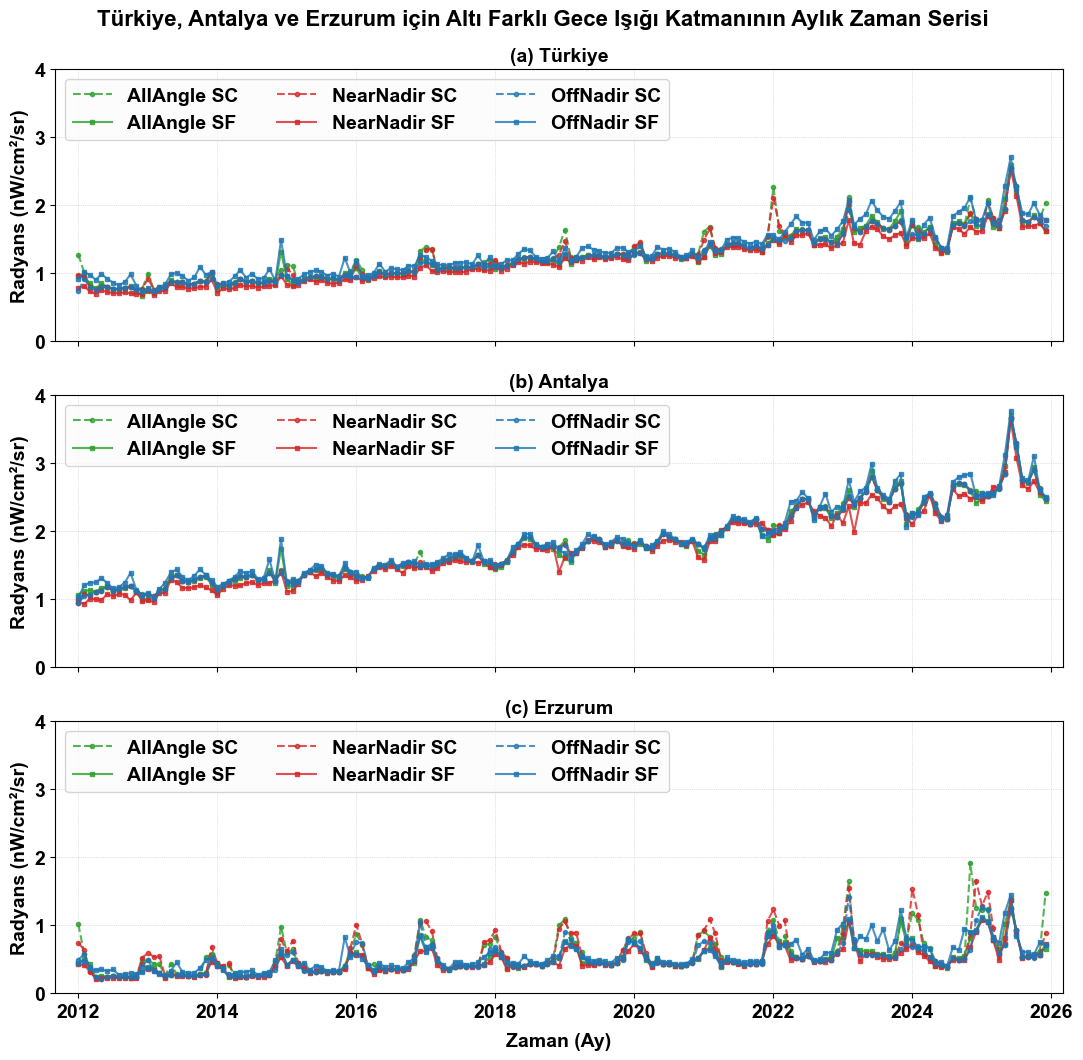

SONUC_RAPORU: ================================================================================
SONUC_RAPORU: 14 YILLIK (2012-2025) ULUSAL VE BÖLGESEL RADYANS İSTATİSTİKLERİ (AYLIK):
SONUC_RAPORU: --------------------------------------------------------------------------------
SONUC_RAPORU: --- TURKIYE GENELİ ORTALAMALARI ---
SONUC_RAPORU: NearNadir SF (En Kararlı Karsız) Ortalama : 1.173607 nW/cm²/sr
SONUC_RAPORU: NearNadir SC (En Kararlı Karlı)  Ortalama : 1.258649 nW/cm²/sr
SONUC_RAPORU: OffNadir SF (En Düşük Karsız)     Ortalama : 1.323528 nW/cm²/sr
SONUC_RAPORU: --------------------------------------------------------------------------------
SONUC_RAPORU: --- ANTALYA GENELİ ORTALAMALARI ---
SONUC_RAPORU: NearNadir SF (En Kararlı Karsız) Ortalama : 1.747471 nW/cm²/sr
SONUC_RAPORU: NearNadir SC (En Kararlı Karlı)  Ortalama : 1.819325 nW/cm²/sr
SONUC_RAPORU: OffNadir SF (En Düşük Karsız)     Ortalama : 1.859662 nW/cm²/sr
SONUC_RAPORU: --------------------------------------------------

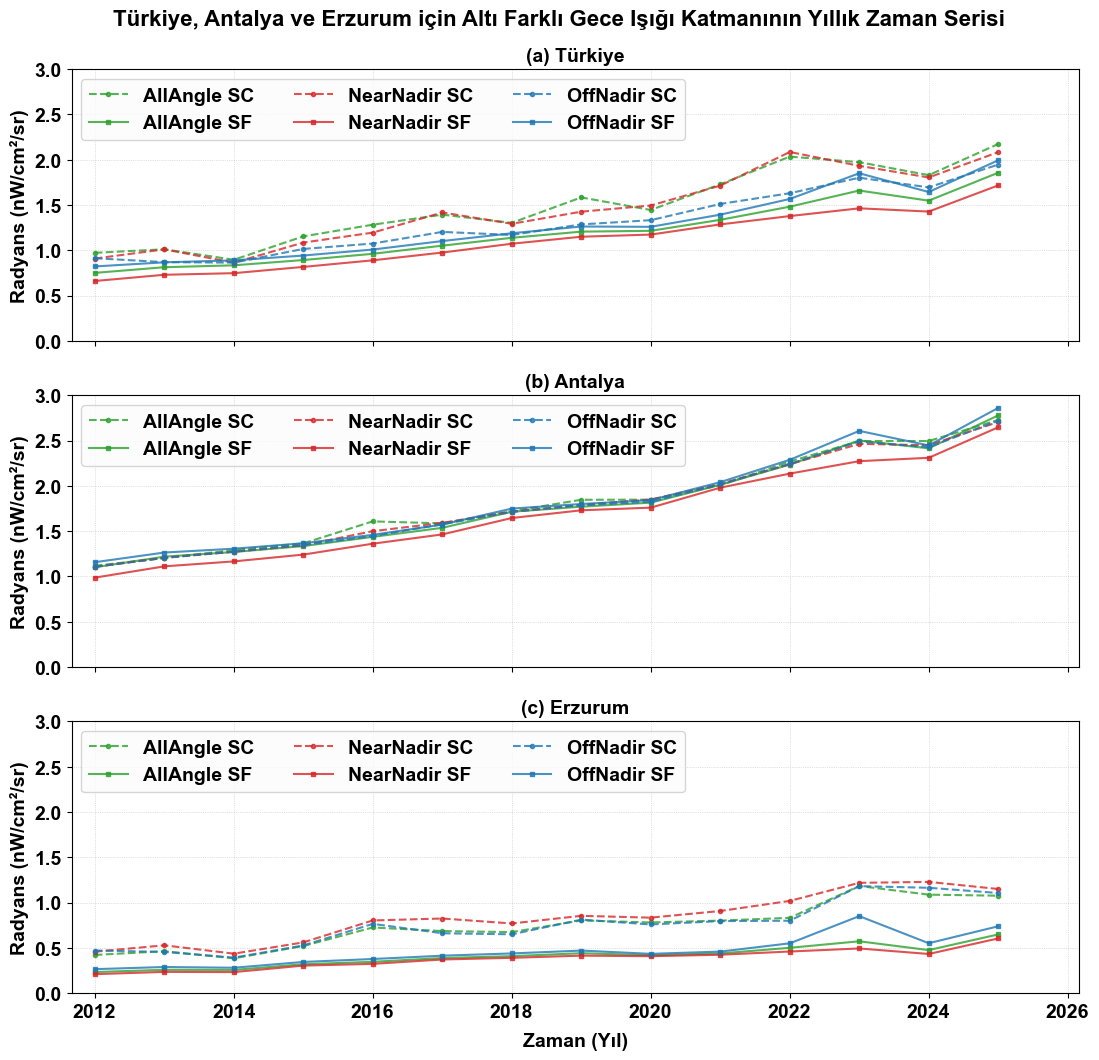

SONUC_RAPORU: ================================================================================
SONUC_RAPORU: 14 YILLIK (2012-2025) ULUSAL VE BÖLGESEL RADYANS İSTATİSTİKLERİ (YILLIK):
SONUC_RAPORU: --------------------------------------------------------------------------------
SONUC_RAPORU: --- TURKIYE GENELİ ORTALAMALARI ---
SONUC_RAPORU: NearNadir SF (En Kararlı Karsız) Ortalama : 1.106738 nW/cm²/sr
SONUC_RAPORU: NearNadir SC (En Kararlı Karlı)  Ortalama : 1.451381 nW/cm²/sr
SONUC_RAPORU: OffNadir SF (En Düşük Karsız)     Ortalama : 1.271130 nW/cm²/sr
SONUC_RAPORU: --------------------------------------------------------------------------------
SONUC_RAPORU: --- ANTALYA GENELİ ORTALAMALARI ---
SONUC_RAPORU: NearNadir SF (En Kararlı Karsız) Ortalama : 1.700964 nW/cm²/sr
SONUC_RAPORU: NearNadir SC (En Kararlı Karlı)  Ortalama : 1.804224 nW/cm²/sr
SONUC_RAPORU: OffNadir SF (En Düşük Karsız)     Ortalama : 1.840138 nW/cm²/sr
SONUC_RAPORU: -------------------------------------------------

In [1]:

# Gerekli modülleri içe aktarıyoruz
import os
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
# Uyarıları kapatıyoruz
warnings.filterwarnings('ignore')

# ==========================================
# MATPLOTLIB RC PARAMETRELERİ
# ==========================================
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans', 'Helvetica', 'sans-serif']
plt.rcParams['mathtext.fontset'] = 'dejavusans'
plt.rcParams['mathtext.default'] = 'regular'
plt.rcParams['font.size'] = 14              # Genel varsayılan yazı boyutu
plt.rcParams['font.weight'] = 'bold'         # Genel kalın yazı
plt.rcParams['axes.labelsize'] = 14          # Eksen etiketleri boyutu
plt.rcParams['axes.titlesize'] = 14          # Alt grafik başlıkları boyutu
plt.rcParams['xtick.labelsize'] = 14         # X koordinat tick boyutları
plt.rcParams['ytick.labelsize'] = 14         # Y koordinat tick boyutları
plt.rcParams['legend.fontsize'] = 14         # Lejant yazı boyutu
plt.rcParams['figure.titlesize'] = 16        # Ana figür başlığı boyutu

def zaman_serisi_grafik_uret(veri_yolu, cikti_yolu, periyot_turu):
    """
    Belirtilen veri setini okur; Türkiye, Antalya ve Erzurum için 6 katmanın
    zaman serisi grafiğini oluşturur ve diske kaydeder.
    """
    if not os.path.exists(veri_yolu):
        raise FileNotFoundError(f"Veri tabanı dosyası bulunamadı! Yolu kontrol edin: {veri_yolu}")

    # Veriyi oku ve indeks olarak tarihi ayarla
    df = pd.read_csv(veri_yolu, sep='\t', parse_dates=['Zaman (UTC)'])
    df.set_index('Zaman (UTC)', inplace=True)

    # 3x1 grafik tasarımının oluşturulması (sharex=True ile zaman ekseni çakıştırılır)
    fig, axs = plt.subplots(3, 1, figsize=(13, 12), sharex=True)

    # Renk ve stil tanımlamaları
    renkler = {
        'AllAngle': '#2ca02c',   # Tüm açılar için yeşil
        'NearNadir': '#d62728',  # Nadire yakın için kırmızı
        'OffNadir': '#1f77b4'    # Eğik açılar için mavi
    }

    # SC (Karlı) -> Kesikli çizgi + daire; SF (Karsız) -> Düz çizgi + kare
    stiller = {
        'SC': {'ls': '--', 'marker': 'o'},
        'SF': {'ls': '-', 'marker': 's'}
    }

    hedef_bolgeler = ['Turkiye', 'Antalya', 'Erzurum']
    
    # Periyot türüne göre grafik başlıklarının düzenlenmesi
    ek_baslik = "Aylık" if periyot_turu == "aylik" else "Yıllık"
    bolge_basliklari = {
        'Turkiye': f'(a) Türkiye',
        'Antalya': f'(b) Antalya',
        'Erzurum': f'(c) Erzurum'
    }

    # Tüm grafiklerin kıyaslanabilirliğini sağlamak için Y ekseni sınırlarını sabitliyoruz
    y_limitleri = (0.0, 4.0) if periyot_turu == "aylik" else (0.0, 3.0)
    
    # Bölgelerin döngüyle çizilmesi
    for idx, bolge in enumerate(hedef_bolgeler):
        ax = axs[idx]
        
        # 6 katmanın bu bölge için çizilmesi
        # AllAngle SC ve SF
        ax.plot(df.index, df[f'{bolge}_AllAngle_SC_mean'], label='AllAngle SC',
                color=renkler['AllAngle'], linestyle=stiller['SC']['ls'], marker=stiller['SC']['marker'], markersize=3.0, alpha=0.8)
        ax.plot(df.index, df[f'{bolge}_AllAngle_SF_mean'], label='AllAngle SF',
                color=renkler['AllAngle'], linestyle=stiller['SF']['ls'], marker=stiller['SF']['marker'], markersize=3.0, alpha=0.8)
        
        # NearNadir SC ve SF
        ax.plot(df.index, df[f'{bolge}_NearNadir_SC_mean'], label='NearNadir SC',
                color=renkler['NearNadir'], linestyle=stiller['SC']['ls'], marker=stiller['SC']['marker'], markersize=3.0, alpha=0.8)
        ax.plot(df.index, df[f'{bolge}_NearNadir_SF_mean'], label='NearNadir SF',
                color=renkler['NearNadir'], linestyle=stiller['SF']['ls'], marker=stiller['SF']['marker'], markersize=3.0, alpha=0.8)
        
        # OffNadir SC ve SF
        ax.plot(df.index, df[f'{bolge}_OffNadir_SC_mean'], label='OffNadir SC',
                color=renkler['OffNadir'], linestyle=stiller['SC']['ls'], marker=stiller['SC']['marker'], markersize=3.0, alpha=0.8)
        ax.plot(df.index, df[f'{bolge}_OffNadir_SF_mean'], label='OffNadir SF',
                color=renkler['OffNadir'], linestyle=stiller['SF']['ls'], marker=stiller['SF']['marker'], markersize=3.0, alpha=0.8)
        
        # Alt grafik düzenlemeleri
        ax.set_title(bolge_basliklari[bolge], fontweight='bold')
        ax.set_ylabel('Radyans (nW/cm²/sr)', fontweight='bold')
        ax.grid(True, which='both', linestyle=':', linewidth=0.5, color='#aaaaaa', alpha=0.7)
        ax.set_ylim(y_limitleri)
        
        # Gösterge kutusu (3 sütunlu geniş yapı)
        ax.legend(loc='upper left', ncol=3, frameon=True, edgecolor='#cccccc', facecolor='#fcfcfc')

    # En alttaki grafik için X ekseni ve tarih formatı ayarı
    x_etiket = 'Zaman (Ay)' if periyot_turu == 'aylik' else 'Zaman (Yıl)'
    axs[2].set_xlabel(x_etiket, fontweight='bold', labelpad=8)
    axs[2].xaxis.set_major_locator(mdates.YearLocator(2))
    axs[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    axs[2].set_xlim(pd.to_datetime('2011-09-01'), pd.to_datetime('2026-03-01'))

    # Üst Başlık
    fig.suptitle(f'Türkiye, Antalya ve Erzurum için Altı Farklı Gece Işığı Katmanının {ek_baslik} Zaman Serisi', 
                 fontweight='bold', y=0.93)

    # Kaydetme işlemi
    plt.savefig(cikti_yolu, dpi=500, bbox_inches='tight')
    plt.show()
    plt.close()

    # Sonuç Raporlama (Konsol Çıktıları)
    print('SONUC_RAPORU: ' + '='*80)
    print(f"SONUC_RAPORU: 14 YILLIK (2012-2025) ULUSAL VE BÖLGESEL RADYANS İSTATİSTİKLERİ ({ek_baslik.upper()}):")
    print('SONUC_RAPORU: ' + '-'*80)
    for bolge in hedef_bolgeler:
        print(f"SONUC_RAPORU: --- {bolge.upper()} GENELİ ORTALAMALARI ---")
        print(f"SONUC_RAPORU: NearNadir SF (En Kararlı Karsız) Ortalama : {df[f'{bolge}_NearNadir_SF_mean'].mean():.6f} nW/cm²/sr")
        print(f"SONUC_RAPORU: NearNadir SC (En Kararlı Karlı)  Ortalama : {df[f'{bolge}_NearNadir_SC_mean'].mean():.6f} nW/cm²/sr")
        print(f"SONUC_RAPORU: OffNadir SF (En Düşük Karsız)     Ortalama : {df[f'{bolge}_OffNadir_SF_mean'].mean():.6f} nW/cm²/sr")
        print('SONUC_RAPORU: ' + '-'*80)
    print(f"SONUC_RAPORU: Zaman Serisi Grafiği Başarıyla Kaydedildi    : {cikti_yolu}")
    print('SONUC_RAPORU: ' + '='*80)

# ==========================================
# ÇALIŞTIRMA BÖLÜMÜ
# ==========================================

# 1. Aylık Verilerin Grafikleştirilmesi (VNP46A3)
zaman_serisi_grafik_uret(
    veri_yolu='=cikti/tsa/=antalya_erzurum_turkiye_monthly_ntl.txt',
    cikti_yolu='=cikti/tsa/SONUC_RAPORU_NTL_TSA_01_alti_katman_zaman_serisi_aylik.png',
    periyot_turu='aylik'
)

# 2. Yıllık Verilerin Grafikleştirilmesi (VNP46A4)
zaman_serisi_grafik_uret(
    veri_yolu='=cikti/tsa/=antalya_erzurum_turkiye_annual_ntl.txt',
    cikti_yolu='=cikti/tsa/SONUC_RAPORU_NTL_TSA_01_alti_katman_zaman_serisi_yillik.png',
    periyot_turu='yillik'
)



## **5.4 Kar Örtüsünün NTL Ölçümleri Üzerindeki Etkisi**

- NTL uydu verileri yorumlanırken, yeryüzünün fiziksel yansıtıcılık (albedo) özelliklerindeki değişimler en önemli bozucu etkenlerden biridir. Özellikle kış aylarında yerdeki kar örtüsü, şehirlerden yayılan yapay ışığı bir ayna gibi atmosfere geri yansıtarak uydunun ölçtüğü radyans değerlerinde yapay bir artışa neden olur. Bu olgu, kentsel büyüme trendlerinin doğru analiz edilmesi önünde ciddi bir engel teşkil edebilmektedir.

- Bu bölümde; 14 yıllık (2012-2025) süreçte kar örtüsünün ve uydunun farklı bakış açılarının (AllAngle, NearNadir, OffNadir) ölçülen radyans değerlerini ne ölçüde etkilediğini nicelleştireceğiz. Aşağıdaki Python kodu, hazırladığımız bütünleşik aylık (VNP46A3) ve yıllık (VNP46A4) veri setlerini okuyarak Türkiye, Erzurum ve Antalya ölçeklerinde Karlı/Karsız Çarpanını (SC/SF oranı) hesaplamaktadır. Bu oran, kar örtüsünün ışık kirliliği sinyalini kaç kat büyüttüğünü hem yüksek frekanslı aylık salınımlar hem de uzun vadeli yıllık eğilimler üzerinden grafiklerle görselleştirmektedir.


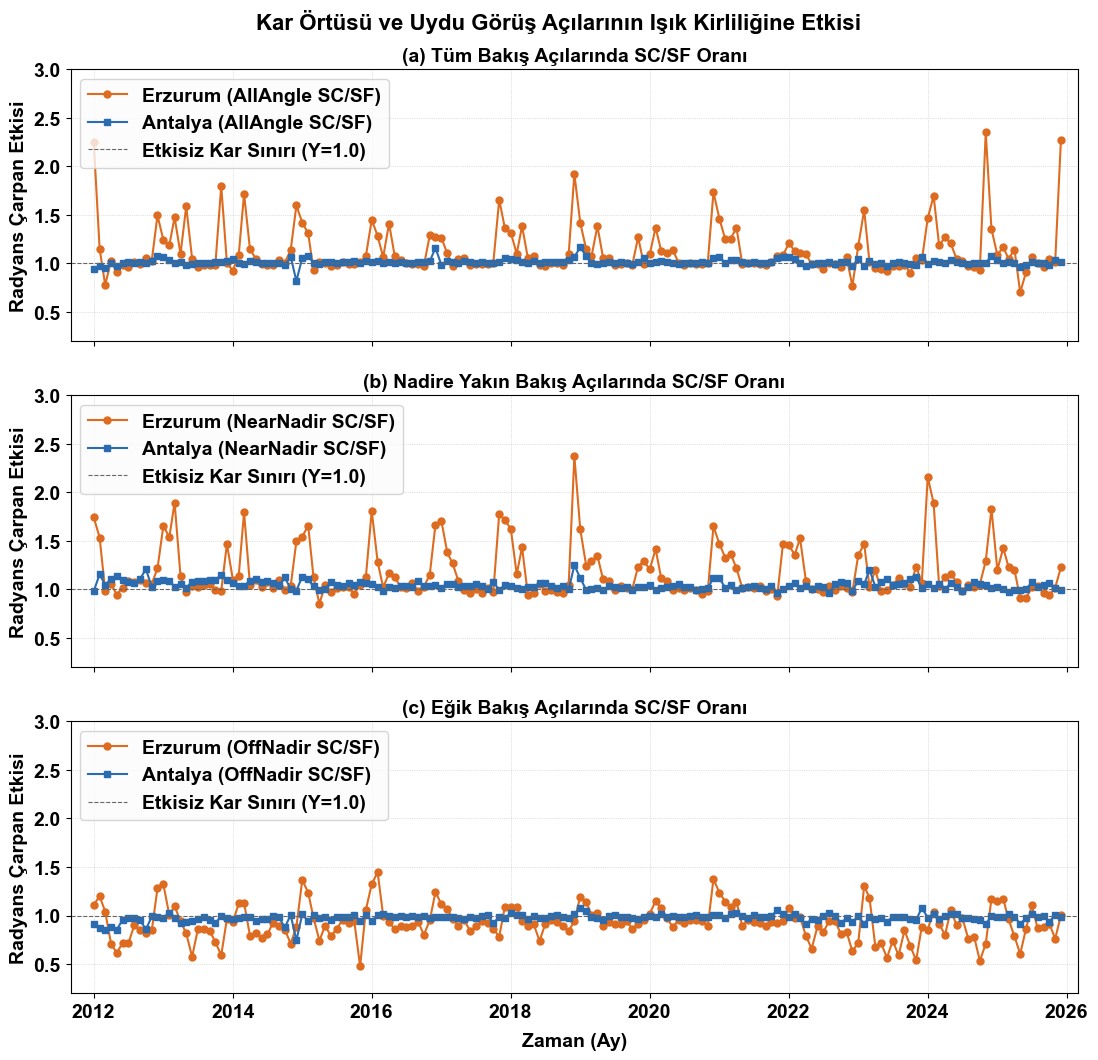

SONUC_RAPORU: ================================================================================
SONUC_RAPORU: 14 YILLIK (2012-2025) UYDU BAKIŞ AÇISI VE KAR ETKİSİ İSTATİSTİKSEL ÖZETİ (AYLIK):
SONUC_RAPORU: --------------------------------------------------------------------------------
SONUC_RAPORU: AllAngle  - Erzurum Ortalama: 1.127277 (Maksimum: 2.349543)
SONUC_RAPORU: AllAngle  - Antalya Ortalama: 1.013091 (Maksimum: 1.162853)
SONUC_RAPORU: --------------------------------------------------------------------------------
SONUC_RAPORU: NearNadir - Erzurum Ortalama: 1.172370 (Maksimum: 2.373005)
SONUC_RAPORU: NearNadir - Antalya Ortalama: 1.045764 (Maksimum: 1.246913)
SONUC_RAPORU: --------------------------------------------------------------------------------
SONUC_RAPORU: OffNadir  - Erzurum Ortalama: 0.923116 (Maksimum: 1.446345)
SONUC_RAPORU: OffNadir  - Antalya Ortalama: 0.976605 (Maksimum: 1.078303)
SONUC_RAPORU: ==================================================================

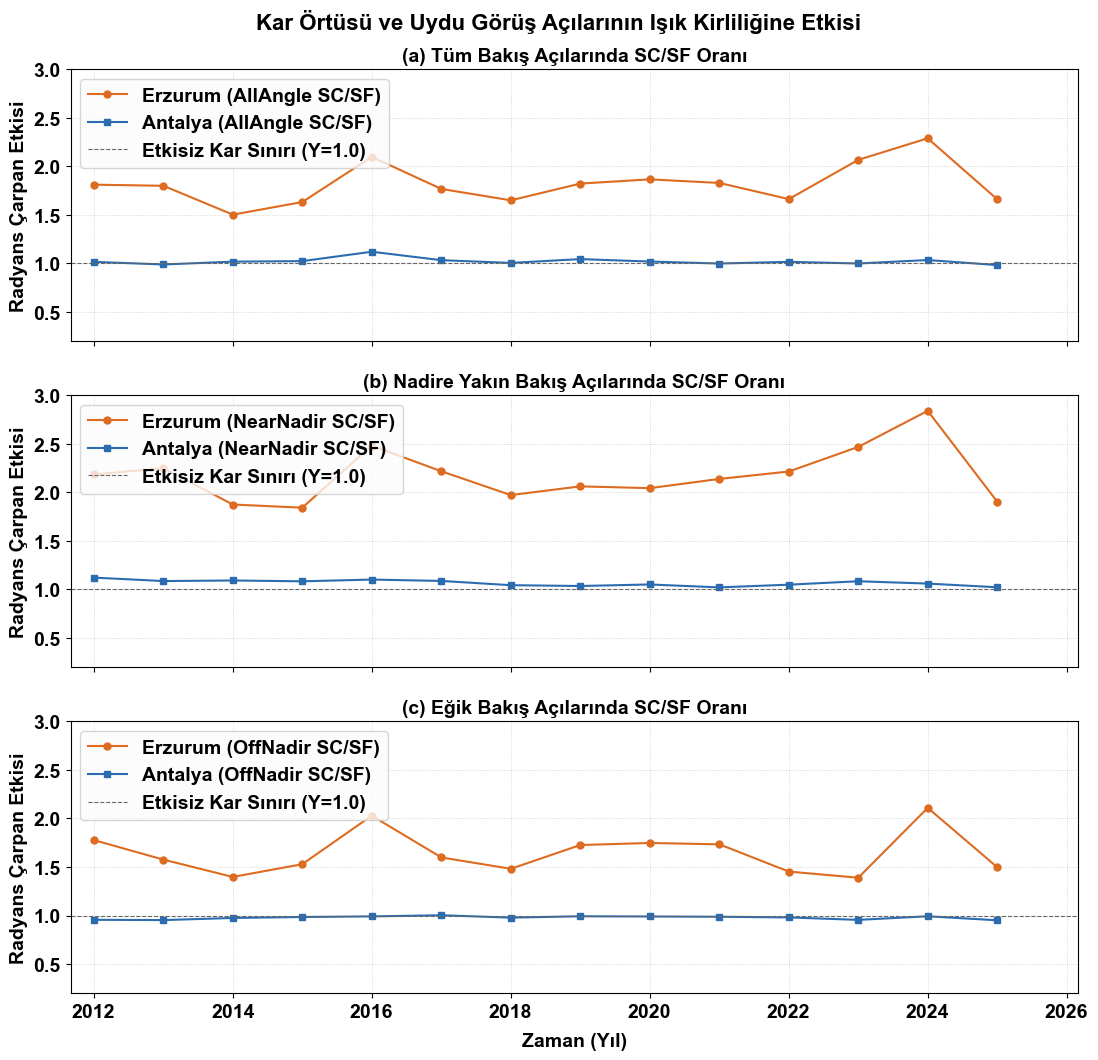

SONUC_RAPORU: ================================================================================
SONUC_RAPORU: 14 YILLIK (2012-2025) UYDU BAKIŞ AÇISI VE KAR ETKİSİ İSTATİSTİKSEL ÖZETİ (YILLIK):
SONUC_RAPORU: --------------------------------------------------------------------------------
SONUC_RAPORU: AllAngle  - Erzurum Ortalama: 1.816959 (Maksimum: 2.287573)
SONUC_RAPORU: AllAngle  - Antalya Ortalama: 1.020180 (Maksimum: 1.119026)
SONUC_RAPORU: --------------------------------------------------------------------------------
SONUC_RAPORU: NearNadir - Erzurum Ortalama: 2.177621 (Maksimum: 2.839724)
SONUC_RAPORU: NearNadir - Antalya Ortalama: 1.066842 (Maksimum: 1.121601)
SONUC_RAPORU: --------------------------------------------------------------------------------
SONUC_RAPORU: OffNadir  - Erzurum Ortalama: 1.645974 (Maksimum: 2.109493)
SONUC_RAPORU: OffNadir  - Antalya Ortalama: 0.977751 (Maksimum: 1.002705)
SONUC_RAPORU: =================================================================

In [1]:

# Gerekli modülleri içe aktarıyoruz
import os
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
# Uyarıları kapatıyoruz
warnings.filterwarnings('ignore')

# ==========================================
# MATPLOTLIB RC PARAMETRELERİ
# ==========================================
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans', 'Helvetica', 'sans-serif']
plt.rcParams['mathtext.fontset'] = 'dejavusans'
plt.rcParams['mathtext.default'] = 'regular'
plt.rcParams['font.size'] = 14              # Genel varsayılan yazı boyutu
plt.rcParams['font.weight'] = 'bold'         # Genel kalın yazı
plt.rcParams['axes.labelsize'] = 14          # Eksen etiketleri boyutu
plt.rcParams['axes.titlesize'] = 14          # Alt grafik başlıkları boyutu
plt.rcParams['xtick.labelsize'] = 14         # X koordinat tick boyutları
plt.rcParams['ytick.labelsize'] = 14         # Y koordinat tick boyutları
plt.rcParams['legend.fontsize'] = 14         # Lejant yazı boyutu
plt.rcParams['figure.titlesize'] = 16        # Ana figür başlığı boyutu

def snowglow_analiz_ciz(veri_yolu, cikti_yolu, periyot_turu):
    """
    Belirtilen veri yolundaki dosyayı okur, AllAngle, NearNadir ve OffNadir
    bakış açıları için kar çarpanlarını (SC/SF) hesaplar, grafiği kaydeder ve raporlar.
    """
    if not os.path.exists(veri_yolu):
        raise FileNotFoundError(f"Veri tabanı dosyası bulunamadı! Yolu kontrol edin: {veri_yolu}")

    # Veriyi oku ve tarih sütununu datetime nesnesi olarak ayarla
    df = pd.read_csv(veri_yolu, sep='\t', parse_dates=['Zaman (UTC)'])
    df.set_index('Zaman (UTC)', inplace=True)

    # Kar Çarpanlarının Hesaplanması (SC / SF)
    df['Antalya_AllAngle_Factor'] = df['Antalya_AllAngle_SC_mean'] / df['Antalya_AllAngle_SF_mean']
    df['Erzurum_AllAngle_Factor'] = df['Erzurum_AllAngle_SC_mean'] / df['Erzurum_AllAngle_SF_mean']

    df['Antalya_NearNadir_Factor'] = df['Antalya_NearNadir_SC_mean'] / df['Antalya_NearNadir_SF_mean']
    df['Erzurum_NearNadir_Factor'] = df['Erzurum_NearNadir_SC_mean'] / df['Erzurum_NearNadir_SF_mean']

    df['Antalya_OffNadir_Factor'] = df['Antalya_OffNadir_SC_mean'] / df['Antalya_OffNadir_SF_mean']
    df['Erzurum_OffNadir_Factor'] = df['Erzurum_OffNadir_SC_mean'] / df['Erzurum_OffNadir_SF_mean']

    # 3x1 Grafik Tasarımı ve Görselleştirme
    fig, axs = plt.subplots(3, 1, figsize=(13, 12), sharex=True)

    # Çizim Parametreleri
    renk_erzurum = '#dd6b20' # '#d95f02'
    renk_antalya = '#2b6cb0' # '#1f77b4'
    marker_size = 5.0
    line_width = 1.5
    alfa_degeri = 1.0
    y_limitleri = (0.2, 3.0)

    # --- Subplot 1: AllAngle (Tüm Açılar) ---
    axs[0].plot(df.index, df['Erzurum_AllAngle_Factor'], label='Erzurum (AllAngle SC/SF)', 
                color=renk_erzurum, linewidth=line_width, marker='o', markersize=marker_size, alpha=alfa_degeri)
    axs[0].plot(df.index, df['Antalya_AllAngle_Factor'], label='Antalya (AllAngle SC/SF)', 
                color=renk_antalya, linewidth=line_width, marker='s', markersize=marker_size, alpha=alfa_degeri)
    axs[0].axhline(y=1.0, color='#666666', linestyle='--', linewidth=0.8, label='Etkisiz Kar Sınırı (Y=1.0)')
    axs[0].set_title('(a) Tüm Bakış Açılarında SC/SF Oranı', fontweight='bold')
    axs[0].set_ylabel('Radyans Çarpan Etkisi', fontweight='bold')
    axs[0].grid(True, which='both', linestyle=':', linewidth=0.5, color='#aaaaaa', alpha=0.7)
    axs[0].legend(loc='upper left', frameon=True, edgecolor='#cccccc', facecolor='#fcfcfc')
    axs[0].set_ylim(y_limitleri)

    # --- Subplot 2: NearNadir (Nadire Yakın Açılar) ---
    axs[1].plot(df.index, df['Erzurum_NearNadir_Factor'], label='Erzurum (NearNadir SC/SF)', 
                color=renk_erzurum, linewidth=line_width, marker='o', markersize=marker_size, alpha=alfa_degeri)
    axs[1].plot(df.index, df['Antalya_NearNadir_Factor'], label='Antalya (NearNadir SC/SF)', 
                color=renk_antalya, linewidth=line_width, marker='s', markersize=marker_size, alpha=alfa_degeri)
    axs[1].axhline(y=1.0, color='#666666', linestyle='--', linewidth=0.8, label='Etkisiz Kar Sınırı (Y=1.0)')
    axs[1].set_title('(b) Nadire Yakın Bakış Açılarında SC/SF Oranı', fontweight='bold')
    axs[1].set_ylabel('Radyans Çarpan Etkisi', fontweight='bold')
    axs[1].grid(True, which='both', linestyle=':', linewidth=0.5, color='#aaaaaa', alpha=0.7)
    axs[1].legend(loc='upper left', frameon=True, edgecolor='#cccccc', facecolor='#fcfcfc')
    axs[1].set_ylim(y_limitleri)

    # --- Subplot 3: OffNadir (Nadir Dışı/Eğik Açılar) ---
    axs[2].plot(df.index, df['Erzurum_OffNadir_Factor'], label='Erzurum (OffNadir SC/SF)', 
                color=renk_erzurum, linewidth=line_width, marker='o', markersize=marker_size, alpha=alfa_degeri)
    axs[2].plot(df.index, df['Antalya_OffNadir_Factor'], label='Antalya (OffNadir SC/SF)', 
                color=renk_antalya, linewidth=line_width, marker='s', markersize=marker_size, alpha=alfa_degeri)
    axs[2].axhline(y=1.0, color='#666666', linestyle='--', linewidth=0.8, label='Etkisiz Kar Sınırı (Y=1.0)')
    axs[2].set_title('(c) Eğik Bakış Açılarında SC/SF Oranı', fontweight='bold')
    
    # Periyoda göre X ekseni etiketini dinamik olarak ayarlıyoruz
    x_etiket = 'Zaman (Ay)' if periyot_turu == 'aylik' else 'Zaman (Yıl)'
    axs[2].set_xlabel(x_etiket, fontweight='bold', labelpad=8)
    axs[2].set_ylabel('Radyans Çarpan Etkisi', fontweight='bold')
    axs[2].grid(True, which='both', linestyle=':', linewidth=0.5, color='#aaaaaa', alpha=0.7)
    axs[2].legend(loc='upper left', frameon=True, edgecolor='#cccccc', facecolor='#fcfcfc')
    axs[2].set_ylim(y_limitleri)

    # X eksenindeki tarih formatı ayarları
    axs[2].xaxis.set_major_locator(mdates.YearLocator(2))
    axs[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    axs[2].set_xlim(pd.to_datetime('2011-09-01'), pd.to_datetime('2026-03-01'))

    # Başlık ve sıkıştırma ayarı
    ek_baslik = 'Aylık' if periyot_turu == 'aylik' else 'Yıllık'
    fig.suptitle(f'Kar Örtüsü ve Uydu Görüş Açılarının Işık Kirliliğine Etkisi', fontweight='bold', y=0.93)

    # Görseli kaydetme işlemleri
    plt.savefig(cikti_yolu, dpi=500, bbox_inches='tight')
    plt.show()
    plt.close()

    # Sonuçların yazdırılması
    print('SONUC_RAPORU: ' + '='*80)
    print(f"SONUC_RAPORU: 14 YILLIK (2012-2025) UYDU BAKIŞ AÇISI VE KAR ETKİSİ İSTATİSTİKSEL ÖZETİ ({ek_baslik.upper()}):")
    print('SONUC_RAPORU: ' + '-'*80)
    print(f"SONUC_RAPORU: AllAngle  - Erzurum Ortalama: {df['Erzurum_AllAngle_Factor'].mean():.6f} (Maksimum: {df['Erzurum_AllAngle_Factor'].max():.6f})")
    print(f"SONUC_RAPORU: AllAngle  - Antalya Ortalama: {df['Antalya_AllAngle_Factor'].mean():.6f} (Maksimum: {df['Antalya_AllAngle_Factor'].max():.6f})")
    print('SONUC_RAPORU: ' + '-'*80)
    print(f"SONUC_RAPORU: NearNadir - Erzurum Ortalama: {df['Erzurum_NearNadir_Factor'].mean():.6f} (Maksimum: {df['Erzurum_NearNadir_Factor'].max():.6f})")
    print(f"SONUC_RAPORU: NearNadir - Antalya Ortalama: {df['Antalya_NearNadir_Factor'].mean():.6f} (Maksimum: {df['Antalya_NearNadir_Factor'].max():.6f})")
    print('SONUC_RAPORU: ' + '-'*80)
    print(f"SONUC_RAPORU: OffNadir  - Erzurum Ortalama: {df['Erzurum_OffNadir_Factor'].mean():.6f} (Maksimum: {df['Erzurum_OffNadir_Factor'].max():.6f})")
    print(f"SONUC_RAPORU: OffNadir  - Antalya Ortalama: {df['Antalya_OffNadir_Factor'].mean():.6f} (Maksimum: {df['Antalya_OffNadir_Factor'].max():.6f})")
    print('SONUC_RAPORU: ' + '='*80)
    print(f"SONUC_RAPORU: Grafik Başarıyla Kaydedildi : {cikti_yolu}")
    print('SONUC_RAPORU: ' + '='*80)

# ==========================================
# ÇALIŞTIRMA BÖLÜMÜ
# ==========================================

# 1. Aylık Kar Çarpan Analiz Grafiğinin Üretilmesi (VNP46A3)
snowglow_analiz_ciz(
    veri_yolu='=cikti/tsa/=antalya_erzurum_turkiye_monthly_ntl.txt',
    cikti_yolu='=cikti/tsa/SONUC_RAPORU_NTL_TSA_02_snowglow_bakis_acilari_karsilastirmasi_aylik.png',
    periyot_turu='aylik'
)

# 2. Yıllık Kar Çarpan Analiz Grafiğinin Üretilmesi (VNP46A4)
snowglow_analiz_ciz(
    veri_yolu='=cikti/tsa/=antalya_erzurum_turkiye_annual_ntl.txt',
    cikti_yolu='=cikti/tsa/SONUC_RAPORU_NTL_TSA_02_snowglow_bakis_acilari_karsilastirmasi_yillik.png',
    periyot_turu='yillik'
)



## **5.5 VIIRS NTL Verilerinin Trend Analizi**

- Yapay gece ışığı emisyonlarındaki uzun dönemli artışı incelemek, gözlemevlerini tehdit eden kümülatif gök parlaması miktarını belirlemek açısından önemlidir.

- Bu bölümde, radyans değerleri üzerinde trend analizleri gerçekleştiriyoruz. Zaman serisi istatistiğinde sıklıkla kullanılan ve birbirini tamamlayan iki güçlü yöntemi bir arada uygulayacağız.

- Parametrik En Küçük Kareler (OLS) Doğrusal Regresyon:Zaman serisi boyunca ortalama yıllık artış miktarını doğrusal bir denklem ($y=ax+b$) ve belirlme katsayısı ($R^2$) ile tahmin etmemizi sağlar.

- Non-Parametrik Mann-Kendall Trend Testi ve Sen's Slope Tahmincisi: Uç değerlere (outliers) karşı son derece dirençli sonuçlar üretir. Sen'in eğim tahmincisi zaman serisindeki yönlü artış hızının medyanını hesaplarken, Mann-Kendall testi bu artışın zaman içinde istatistiksel olarak ne derece tek yönlü (kesintisiz) olduğunu doğrular.

- Aşağıdaki Python kodu; bu parametrik ve non-parametrik analizleri entegre şekilde yürüterek, hem aylık (VNP46A3) hem de yıllık (VNP46A4) veri setlerimizi sırasıyla analiz etmekte ve sonuçları görselleştirmektedir.


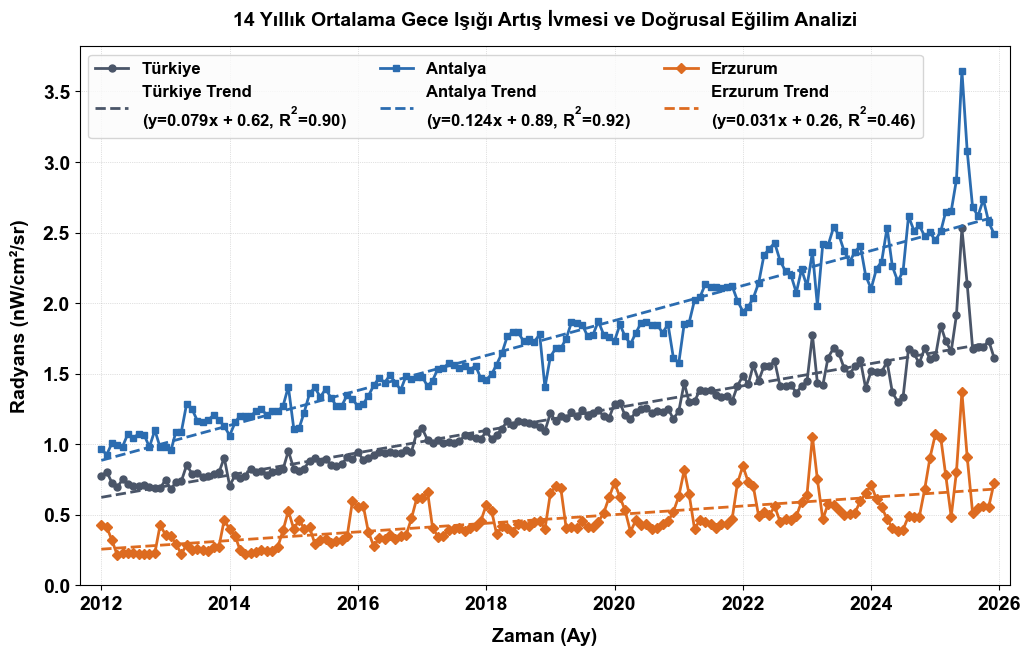

SONUC_RAPORU: ================================================================================
SONUC_RAPORU: 14 YILLIK (2012-2025) BÖLGESEL MUTLAK TREND ANALİZİ (AYLIK):
SONUC_RAPORU: --------------------------------------------------------------------------------
SONUC_RAPORU: --- TURKIYE İSTATİSTİKSEL TREND BİLGİLERİ ---
SONUC_RAPORU: Toplam Yüzdesel Değişim (2012->2025)  : %108.45
SONUC_RAPORU: Yıllık Mutlak OLS Artış Hızı (Eğim)   : 0.079004 nW/cm²/sr/yıl
SONUC_RAPORU: Yıllık Mutlak Sen's Slope Tahmincisi : 0.075878 nW/cm²/sr/yıl
SONUC_RAPORU: Doğrusal OLS Denklemi (Lineer Fit)   : y = 0.0790x + 0.6239
SONUC_RAPORU: Belirlenim Katsayısı (OLS R2 Değeri)  : 0.9008
SONUC_RAPORU: OLS Regresyon Anlamlılığı (p-değeri)  : 0.00000000
SONUC_RAPORU: Mann-Kendall S İstatistiği             : 12338.0
SONUC_RAPORU: Mann-Kendall Z Skoru                   : 16.9222
SONUC_RAPORU: Mann-Kendall Anlamlılığı (p-değeri)    : 0.00000000
SONUC_RAPORU: ------------------------------------------------------

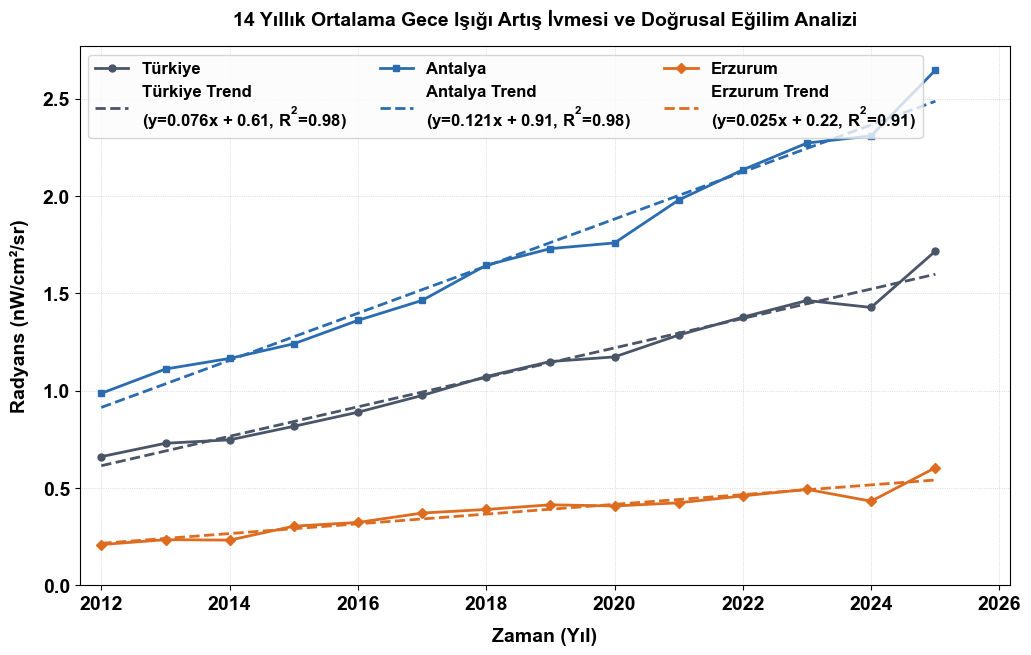

SONUC_RAPORU: ================================================================================
SONUC_RAPORU: 14 YILLIK (2012-2025) BÖLGESEL MUTLAK TREND ANALİZİ (YILLIK):
SONUC_RAPORU: --------------------------------------------------------------------------------
SONUC_RAPORU: --- TURKIYE İSTATİSTİKSEL TREND BİLGİLERİ ---
SONUC_RAPORU: Toplam Yüzdesel Değişim (2012->2025)  : %159.61
SONUC_RAPORU: Yıllık Mutlak OLS Artış Hızı (Eğim)   : 0.075670 nW/cm²/sr/yıl
SONUC_RAPORU: Yıllık Mutlak Sen's Slope Tahmincisi : 0.075981 nW/cm²/sr/yıl
SONUC_RAPORU: Doğrusal OLS Denklemi (Lineer Fit)   : y = 0.0757x + 0.6148
SONUC_RAPORU: Belirlenim Katsayısı (OLS R2 Değeri)  : 0.9764
SONUC_RAPORU: OLS Regresyon Anlamlılığı (p-değeri)  : 0.00000000
SONUC_RAPORU: Mann-Kendall S İstatistiği             : 89.0
SONUC_RAPORU: Mann-Kendall Z Skoru                   : 4.8176
SONUC_RAPORU: Mann-Kendall Anlamlılığı (p-değeri)    : 0.00000145
SONUC_RAPORU: ---------------------------------------------------------

In [1]:

# Gerekli modülleri içe aktarıyoruz
import os
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.stats import linregress, norm
import warnings
# Uyarıları kapatıyoruz
warnings.filterwarnings('ignore')

# ==========================================
# MATPLOTLIB RC PARAMETRELERİ
# ==========================================
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans', 'Helvetica', 'sans-serif']
plt.rcParams['mathtext.fontset'] = 'dejavusans'
plt.rcParams['mathtext.default'] = 'regular'
plt.rcParams['font.size'] = 14              # Genel varsayılan yazı boyutu
plt.rcParams['font.weight'] = 'bold'         # Genel kalın yazı
plt.rcParams['axes.labelsize'] = 14          # Eksen etiketleri boyutu
plt.rcParams['axes.titlesize'] = 14          # Alt grafik başlıkları boyutu
plt.rcParams['xtick.labelsize'] = 14         # X koordinat tick boyutları
plt.rcParams['ytick.labelsize'] = 14         # Y koordinat tick boyutları
plt.rcParams['legend.fontsize'] = 12         # Lejant yazı boyutu
plt.rcParams['figure.titlesize'] = 16        # Ana figür başlığı boyutu

def orjinal_trend_analizi_uret(veri_yolu, cikti_yolu, periyot_turu):
    """
    Belirtilen orijinal veri setini okur; Türkiye, Antalya ve Erzurum için 
    aylık ve yıllık bazda OLS Regresyonu, Mann-Kendall Testi ve Sen's Slope analizlerini yapar.
    """
    if not os.path.exists(veri_yolu):
        raise FileNotFoundError(f"Veri tabanı dosyası bulunamadı! Yolu kontrol edin: {veri_yolu}")

    # Veriyi okuma ve hazırlama
    df = pd.read_csv(veri_yolu, sep='\t', parse_dates=['Zaman (UTC)'])
    df.set_index('Zaman (UTC)', inplace=True)

    # Karşılaştırılacak hedef sütunlar
    analiz_sutunlari = {
        'Turkiye': 'Turkiye_NearNadir_SF_mean',
        'Antalya': 'Antalya_NearNadir_SF_mean',
        'Erzurum': 'Erzurum_NearNadir_SF_mean'
    }

    büyüme_hizlari = {}

    # Orijinal Değerler Üzerinden İstatistiksel Analiz Döngüsü
    for etiket, sutun_adi in list(analiz_sutunlari.items()):
        df_clean = df[[sutun_adi]].dropna()
        x_gunler = (df_clean.index - df_clean.index[0]).days.values
        y_radyans = df_clean[sutun_adi].values
        n = len(y_radyans)
        
        # ---------------------------------------------------------
        # 1. PARAMETRİK ANALİZ: En Küçük Kareler (OLS) Doğrusal Regresyonu
        # ---------------------------------------------------------
        egim, intercept, r_value, p_value, std_err = linregress(x_gunler, y_radyans)
        yillik_mutlak_artis = egim * 365.25
        fit_yol = x_gunler * egim + intercept
        
        # ---------------------------------------------------------
        # 2. NON-PARAMETRİK ANALİZ 1: Sen'in Eğim Tahmincisi
        # ---------------------------------------------------------
        ikili_egimler = []
        for i in range(n):
            for j in range(i + 1, n):
                dy = y_radyans[j] - y_radyans[i]
                dx = x_gunler[j] - x_gunler[i]
                if dx != 0:
                    ikili_egimler.append(dy / dx)
        sens_slope_gunluk = np.median(ikili_egimler)
        sens_slope_yillik = sens_slope_gunluk * 365.25 # Yıllık mutlak artışa dönüştürme (nW/cm²/sr/yıl)
        
        # ---------------------------------------------------------
        # 3. NON-PARAMETRİK ANALİZ 2: Mann-Kendall Trend Testi (S, Z ve p değerleri)
        # ---------------------------------------------------------
        S = 0
        for i in range(n):
            for j in range(i + 1, n):
                S += np.sign(y_radyans[j] - y_radyans[i])
                
        # S varyansı hesabı (bağlar/ties ihmal edilmiştir, kesintisiz veri için standart formül)
        S_varyans = (n * (n - 1) * (2 * n + 5)) / 18.0
        
        # Z-skoru standartlaştırması
        if S > 0:
            z_skoru = (S - 1) / np.sqrt(S_varyans)
        elif S < 0:
            z_skoru = (S + 1) / np.sqrt(S_varyans)
        else:
            z_skoru = 0.0
            
        # Çift kuyruklu (two-tailed) Mann-Kendall p-değeri hesabı
        p_degeri_mk = 2 * (1 - norm.cdf(abs(z_skoru))) if z_skoru != 0 else 1.0
        
        # Toplam yüzdesel değişim hesabı (2012 -> 2025)
        baslangic = y_radyans[0]
        bitis = y_radyans[-1]
        toplam_yuzde = ((bitis - baslangic) / baslangic) * 100.0 if baslangic > 0 else 0.0
        
        # Elde edilen tüm parametrik ve non-parametrik sonuçları kaydediyoruz
        büyüme_hizlari[etiket] = {
            'eğim': yillik_mutlak_artis,
            'intercept': intercept,
            'R2': r_value**2,
            'p-değeri': p_value,
            'fit_x': df_clean.index,
            'fit_y': fit_yol,
            'toplam_yuzde': toplam_yuzde,
            'y_clean': y_radyans,
            'sens_slope': sens_slope_yillik,
            'MK_S': S,
            'MK_Z': z_skoru,
            'MK_p': p_degeri_mk
        }

    # Grafik Tasarımı ve Çizim
    plt.figure(figsize=(12, 7))

    """
    grafik_parametreleri = {
        'Turkiye': {'renk': '#2ca02c', 'marker': 'o', 'stil': '-', 'label': 'Türkiye'},
        'Antalya': {'renk': '#1f77b4', 'marker': 's', 'stil': '-', 'label': 'Antalya'},
        'Erzurum': {'renk': '#d95f02', 'marker': 'D', 'stil': '-', 'label': 'Erzurum'}
    }"""

    grafik_parametreleri = {
        'Turkiye': {'renk': '#4a5568', 'marker': 'o', 'stil': '-', 'label': 'Türkiye'},
        'Antalya': {'renk': '#2b6cb0', 'marker': 's', 'stil': '-', 'label': 'Antalya'},
        'Erzurum': {'renk': '#dd6b20', 'marker': 'D', 'stil': '-', 'label': 'Erzurum'}
    }


    for etiket in list(büyüme_hizlari.keys()):
        params = grafik_parametreleri[etiket]
        
        # 1. Gerçek Veri Eğrisi (Orijinal değerler)
        plt.plot(büyüme_hizlari[etiket]['fit_x'], büyüme_hizlari[etiket]['y_clean'], 
                 label=f"{params['label']}",
                 color=params['renk'], 
                 marker=params['marker'], 
                 linestyle=params['stil'], 
                 linewidth=2.0, 
                 markersize=5, 
                 alpha=1.0)
        
        # 2. Lineer Fit Çizgisi
        plt.plot(büyüme_hizlari[etiket]['fit_x'], büyüme_hizlari[etiket]['fit_y'],
                 label=f"{params['label']} Trend\n(y={büyüme_hizlari[etiket]['eğim']:.3f}x + {büyüme_hizlari[etiket]['intercept']:.2f}, $R^2$={büyüme_hizlari[etiket]['R2']:.2f})",
                 color=params['renk'],
                 linestyle='--',
                 linewidth=2.0,
                 alpha=1.0)

    # Başlık ve Eksen Biçimlendirmeleri
    periyot_adi = "Aylık" if periyot_turu == "aylik" else "Yıllık"
    plt.title(f'14 Yıllık Ortalama Gece Işığı Artış İvmesi ve Doğrusal Eğilim Analizi', fontweight='bold', pad=15)
    
    # Periyoda göre X ekseni etiketini dinamik olarak ayarlıyoruz
    x_etiket = 'Zaman (Ay)' if periyot_turu == 'aylik' else 'Zaman (Yıl)'
    plt.xlabel(x_etiket, fontweight='bold', labelpad=10)
    plt.ylabel('Radyans (nW/cm²/sr)', fontweight='bold', labelpad=10)
    plt.grid(True, which='both', linestyle=':', linewidth=0.5, color='#aaaaaa', alpha=0.7)

    # X ekseni zaman aralığı sınırlandırması
    plt.xlim(pd.to_datetime('2011-09-01'), pd.to_datetime('2026-03-01'))
    plt.gca().xaxis.set_major_locator(mdates.YearLocator(2))
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    # Dikey eksen başlangıç değerini sıfıra sabitliyoruz
    plt.ylim(bottom=0.0)

    # Lejant kutusu
    plt.legend(loc='upper left', ncol=3, frameon=True, edgecolor='#cccccc', facecolor='#fcfcfc')

    # Kaydetme
    plt.savefig(cikti_yolu, dpi=500, bbox_inches='tight')
    plt.show()
    plt.close()

    # Sonuç Raporlama (Konsol Çıktıları - Mann-Kendall ve Sen's Slope Entegre Edilmiştir)
    print('SONUC_RAPORU: ' + '='*80)
    print(f"SONUC_RAPORU: 14 YILLIK (2012-2025) BÖLGESEL MUTLAK TREND ANALİZİ ({periyot_adi.upper()}):")
    print('SONUC_RAPORU: ' + '-'*80)
    for etiket, veri in büyüme_hizlari.items():
        print(f"SONUC_RAPORU: --- {etiket.upper()} İSTATİSTİKSEL TREND BİLGİLERİ ---")
        print(f"SONUC_RAPORU: Toplam Yüzdesel Değişim (2012->2025)  : %{veri['toplam_yuzde']:.2f}")
        print(f"SONUC_RAPORU: Yıllık Mutlak OLS Artış Hızı (Eğim)   : {veri['eğim']:.6f} nW/cm²/sr/yıl")
        print(f"SONUC_RAPORU: Yıllık Mutlak Sen's Slope Tahmincisi : {veri['sens_slope']:.6f} nW/cm²/sr/yıl")
        print(f"SONUC_RAPORU: Doğrusal OLS Denklemi (Lineer Fit)   : y = {veri['eğim']:.4f}x + {veri['intercept']:.4f}")
        print(f"SONUC_RAPORU: Belirlenim Katsayısı (OLS R2 Değeri)  : {veri['R2']:.4f}")
        print(f"SONUC_RAPORU: OLS Regresyon Anlamlılığı (p-değeri)  : {veri['p-değeri']:.8f}")
        print(f"SONUC_RAPORU: Mann-Kendall S İstatistiği             : {veri['MK_S']:.1f}")
        print(f"SONUC_RAPORU: Mann-Kendall Z Skoru                   : {veri['MK_Z']:.4f}")
        print(f"SONUC_RAPORU: Mann-Kendall Anlamlılığı (p-değeri)    : {veri['MK_p']:.8f}")
        print('SONUC_RAPORU: ' + '-'*80)
    print(f"SONUC_RAPORU: Grafik Başarıyla Kaydedildi                  : {cikti_yolu}")
    print('SONUC_RAPORU: ' + '='*80)

# ==========================================
# ÇALIŞTIRMA BÖLÜMÜ
# ==========================================

# 1. Aylık Orijinal Değer Trend Analizinin Çalıştırılması
orjinal_trend_analizi_uret(
    veri_yolu='=cikti/tsa/=antalya_erzurum_turkiye_monthly_ntl.txt',
    cikti_yolu='=cikti/tsa/SONUC_RAPORU_NTL_TSA_03_trend_analizi_aylik.png',
    periyot_turu='aylik'
)

# 2. Yıllık Orijinal Değer Trend Analizinin Çalıştırılması
orjinal_trend_analizi_uret(
    veri_yolu='=cikti/tsa/=antalya_erzurum_turkiye_annual_ntl.txt',
    cikti_yolu='=cikti/tsa/SONUC_RAPORU_NTL_TSA_03_trend_analizi_yillik.png',
    periyot_turu='yillik'
)



## **5.6 Gözlemevleri Yerleşkelerinde NTL Değerleri**

- Yerleşke konumu ile hemen yakınlarındaki tampon bölgelerin uzun vadeli gelişimini kıyaslayacağız.

- 14 yıllık NearNadir_SF verisinde, TUG ve DAG için (1x1 piksel), (9x9 piksel) ve (21x21 piksel) değerleri karşılaştırılıyor.

- Bu analiz bize "Gözlemevlerinin tam üzerindeki piksel (1x1) karanlık kalmayı başarabilmiş mi, yoksa etrafındaki tampon bölgedeki ışık sızıntısı teleskop konumunu da etkilemeye başlamış mı?" sorusunun yanıtını verecektir.

- Bu bulgu, yerel koruma politikalarının başarısını doğrudan test eder.


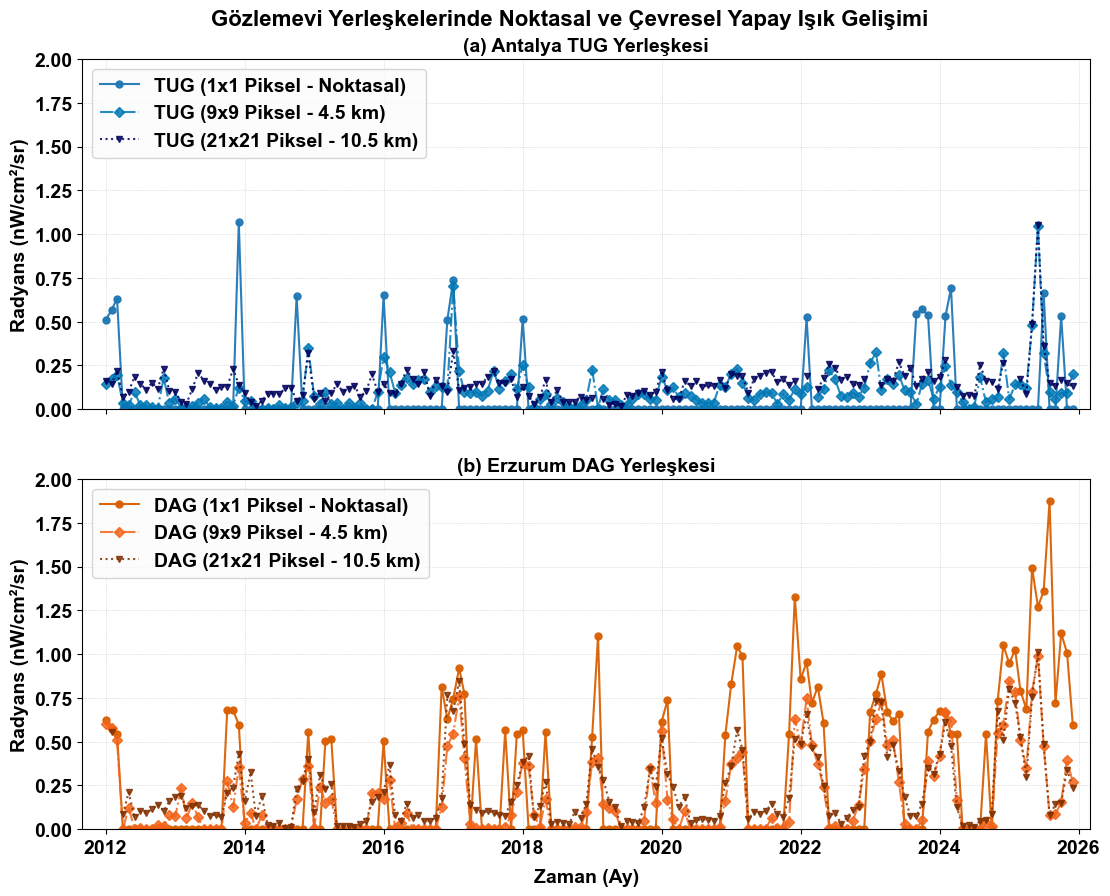

SONUC_RAPORU: ================================================================================
SONUC_RAPORU: GÖZLEMEVİ YEREL TEHDİT İSTATİSTİKLERİ (AYLIK):
SONUC_RAPORU: --------------------------------------------------------------------------------
SONUC_RAPORU: --- TUG GÖZLEMEVİ ---
SONUC_RAPORU: 1x1 Piksel (0.5 km) Ortalama : 0.062109 nW/cm²/sr
SONUC_RAPORU: 9x9 Piksel (4.5 km Tampon)  Ortalama : 0.105600 nW/cm²/sr
SONUC_RAPORU: 21x21 Piksel (10.5 km Havza) Ortalama : 0.142618 nW/cm²/sr
SONUC_RAPORU: Maksimum Kentsel Havza Sızıntısı Farkı: 0.080509 nW/cm²/sr
SONUC_RAPORU: --------------------------------------------------------------------------------
SONUC_RAPORU: --- DAG GÖZLEMEVİ ---
SONUC_RAPORU: 1x1 Piksel (0.5 km) Ortalama : 0.284004 nW/cm²/sr
SONUC_RAPORU: 9x9 Piksel (4.5 km Tampon)  Ortalama : 0.178601 nW/cm²/sr
SONUC_RAPORU: 21x21 Piksel (10.5 km Havza) Ortalama : 0.221196 nW/cm²/sr
SONUC_RAPORU: Maksimum Kentsel Havza Sızıntısı Farkı: -0.062808 nW/cm²/sr
SONUC_RAPORU: ---

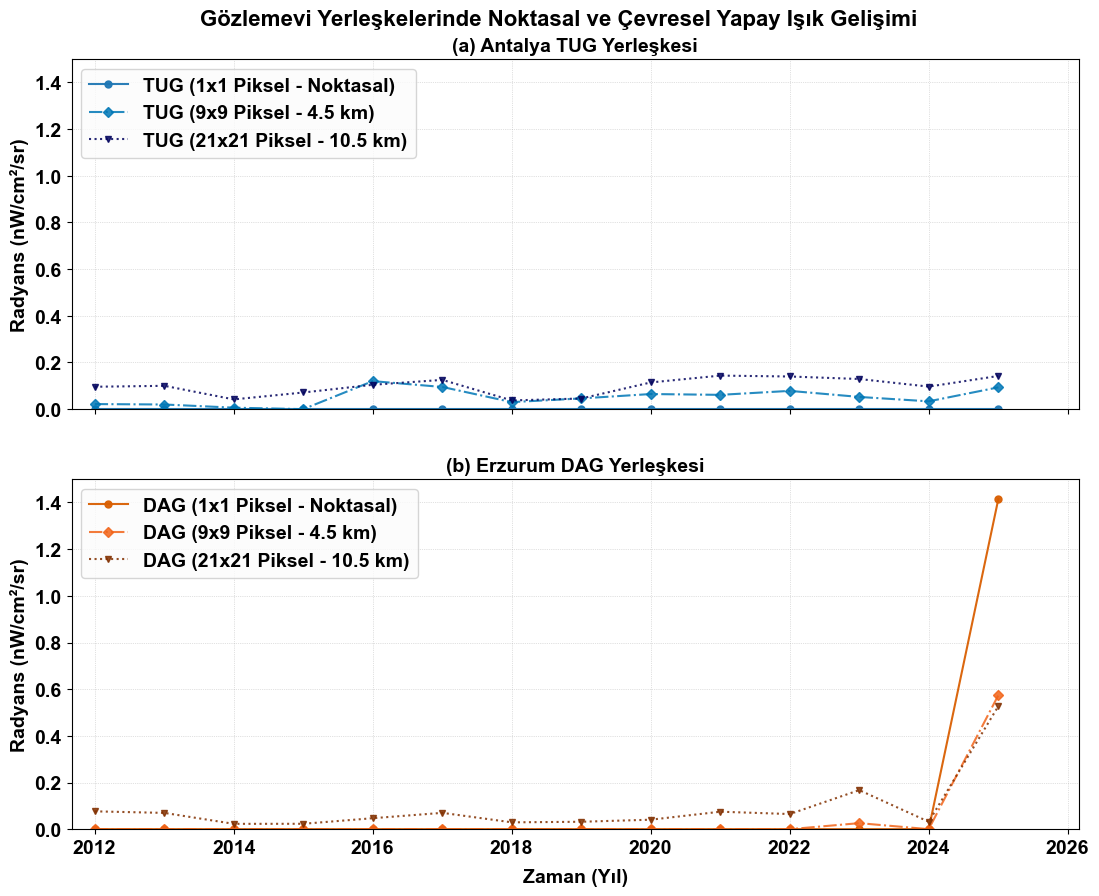

SONUC_RAPORU: ================================================================================
SONUC_RAPORU: GÖZLEMEVİ YEREL TEHDİT İSTATİSTİKLERİ (YILLIK):
SONUC_RAPORU: --------------------------------------------------------------------------------
SONUC_RAPORU: --- TUG GÖZLEMEVİ ---
SONUC_RAPORU: 1x1 Piksel (0.5 km) Ortalama : 0.000000 nW/cm²/sr
SONUC_RAPORU: 9x9 Piksel (4.5 km Tampon)  Ortalama : 0.051701 nW/cm²/sr
SONUC_RAPORU: 21x21 Piksel (10.5 km Havza) Ortalama : 0.099228 nW/cm²/sr
SONUC_RAPORU: Maksimum Kentsel Havza Sızıntısı Farkı: 0.099228 nW/cm²/sr
SONUC_RAPORU: --------------------------------------------------------------------------------
SONUC_RAPORU: --- DAG GÖZLEMEVİ ---
SONUC_RAPORU: 1x1 Piksel (0.5 km) Ortalama : 0.101086 nW/cm²/sr
SONUC_RAPORU: 9x9 Piksel (4.5 km Tampon)  Ortalama : 0.042861 nW/cm²/sr
SONUC_RAPORU: 21x21 Piksel (10.5 km Havza) Ortalama : 0.091177 nW/cm²/sr
SONUC_RAPORU: Maksimum Kentsel Havza Sızıntısı Farkı: -0.009910 nW/cm²/sr
SONUC_RAPORU: --

In [1]:

# Gerekli modülleri içe aktarıyoruz
import os
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
# Uyarıları kapatıyoruz
warnings.filterwarnings('ignore')

# ==========================================
# MATPLOTLIB RC PARAMETRELERİ
# ==========================================
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans', 'Helvetica', 'sans-serif']
plt.rcParams['mathtext.fontset'] = 'dejavusans'
plt.rcParams['mathtext.default'] = 'regular'
plt.rcParams['font.size'] = 14              # Genel varsayılan yazı boyutu
plt.rcParams['font.weight'] = 'bold'         # Genel kalın yazı
plt.rcParams['axes.labelsize'] = 14          # Eksen etiketleri boyutu
plt.rcParams['axes.titlesize'] = 14          # Alt grafik başlıkları boyutu
plt.rcParams['xtick.labelsize'] = 14         # X koordinat tick boyutları
plt.rcParams['ytick.labelsize'] = 14         # Y koordinat tick boyutları
plt.rcParams['legend.fontsize'] = 14         # Lejant yazı boyutu
plt.rcParams['figure.titlesize'] = 16        # Ana figür başlığı boyutu

def gozlemevi_lokal_analiz_uret(veri_yolu, cikti_yolu, periyot_turu):
    """
    Belirtilen veri setini okur; TUG ve DAG yerleşkeleri için en kararlı katman (NearNadir_SF)
    üzerinden 1x1, 9x9 ve 21x21 piksel pencerelerinin zaman serilerini grafikleştirir.
    """
    if not os.path.exists(veri_yolu):
        raise FileNotFoundError(f"Veri tabanı dosyası bulunamadı! Yolu kontrol edin: {veri_yolu}")

    # Veriyi oku ve indeks olarak tarihi ayarla
    df = pd.read_csv(veri_yolu, sep='\t', parse_dates=['Zaman (UTC)'])
    df.set_index('Zaman (UTC)', inplace=True)

    # 2x1 dikey grafik yapısının kurulması
    fig, axs = plt.subplots(2, 1, figsize=(13, 10), sharex=True)

    # Bölgesel Renk Temaları: TUG - Mavi Tonları, DAG - Turuncu Tonları
    renkler = {
        'TUG': {'1x1': '#1f77b4', '9x9': '#0077b6', '21x21': '#03045e'},
        'DAG': {'1x1': '#d95f02', '9x9': '#f26419', '21x21': '#823000'}
    }

    # Gözlemevleri için karanlık alan hassasiyetini koruyacak şekilde Y sınırları tanımlanıyor
    # Aylık veriler için 0.0 - 2.0, Yıllık veriler için daha dar olan 0.0 - 1.5 aralığı seçilmiştir
    y_limitleri = (0.0, 2.0) if periyot_turu == "aylik" else (0.0, 1.5)
    periyot_adi = "Aylık" if periyot_turu == "aylik" else "Yıllık"

    # --- 1. SUBPLOT: TUG (Bakırlıtepe, Antalya) ---
    axs[0].plot(df.index, df['TUG_NearNadir_SF_1x1_mean'], 
                label='TUG (1x1 Piksel - Noktasal)',
                color=renkler['TUG']['1x1'], linestyle='-', marker='o', markersize=5, alpha=0.95)
    axs[0].plot(df.index, df['TUG_NearNadir_SF_9x9_mean'], 
                label='TUG (9x9 Piksel - 4.5 km)',
                color=renkler['TUG']['9x9'], linestyle='-.', marker='D', markersize=5, alpha=0.85)
    axs[0].plot(df.index, df['TUG_NearNadir_SF_21x21_mean'], 
                label='TUG (21x21 Piksel - 10.5 km)',
                color=renkler['TUG']['21x21'], linestyle=':', marker='v', markersize=5, alpha=0.85)
    
    axs[0].set_title(f'(a) Antalya TUG Yerleşkesi', fontweight='bold')
    axs[0].set_ylabel('Radyans (nW/cm²/sr)', fontweight='bold')
    axs[0].set_ylim(y_limitleri)
    axs[0].grid(True, which='both', linestyle=':', linewidth=0.5, color='#aaaaaa', alpha=0.7)
    axs[0].legend(loc='upper left', ncol=1, frameon=True, edgecolor='#cccccc', facecolor='#fcfcfc')

    # --- 2. SUBPLOT: DAG (Karakaya Tepesi, Erzurum) ---
    axs[1].plot(df.index, df['DAG_NearNadir_SF_1x1_mean'], 
                label='DAG (1x1 Piksel - Noktasal)',
                color=renkler['DAG']['1x1'], linestyle='-', marker='o', markersize=5, alpha=0.95)
    axs[1].plot(df.index, df['DAG_NearNadir_SF_9x9_mean'], 
                label='DAG (9x9 Piksel - 4.5 km)',
                color=renkler['DAG']['9x9'], linestyle='-.', marker='D', markersize=5, alpha=0.85)
    axs[1].plot(df.index, df['DAG_NearNadir_SF_21x21_mean'], 
                label='DAG (21x21 Piksel - 10.5 km)',
                color=renkler['DAG']['21x21'], linestyle=':', marker='v', markersize=5, alpha=0.85)
    
    axs[1].set_title(f'(b) Erzurum DAG Yerleşkesi', fontweight='bold')
    axs[1].set_ylabel('Radyans (nW/cm²/sr)', fontweight='bold')
    axs[1].set_ylim(y_limitleri)
    axs[1].grid(True, which='both', linestyle=':', linewidth=0.5, color='#aaaaaa', alpha=0.7)
    axs[1].legend(loc='upper left', ncol=1, frameon=True, edgecolor='#cccccc', facecolor='#fcfcfc')

    # X ekseni ve tarih ayarları (En alttaki grafik için uygulanır)
    x_etiket = 'Zaman (Ay)' if periyot_turu == 'aylik' else 'Zaman (Yıl)'
    axs[1].set_xlabel(x_etiket, fontweight='bold', labelpad=8)
    axs[1].xaxis.set_major_locator(mdates.YearLocator(2))
    axs[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    axs[1].set_xlim(pd.to_datetime('2011-09-01'), pd.to_datetime('2026-03-01'))

    # Üst Başlık
    fig.suptitle(f'Gözlemevi Yerleşkelerinde Noktasal ve Çevresel Yapay Işık Gelişimi', fontweight='bold', y=0.93)

    # Kaydetme
    plt.savefig(cikti_yolu, dpi=500, bbox_inches='tight')
    plt.show()
    plt.close()

    # Sonuç Raporlama
    print('SONUC_RAPORU: ' + '='*80)
    print(f"SONUC_RAPORU: GÖZLEMEVİ YEREL TEHDİT İSTATİSTİKLERİ ({periyot_adi.upper()}):")
    print('SONUC_RAPORU: ' + '-'*80)
    for obs in ['TUG', 'DAG']:
        v_1x1 = df[f"{obs}_NearNadir_SF_1x1_mean"].dropna()
        v_9x9 = df[f"{obs}_NearNadir_SF_9x9_mean"].dropna()
        v_21x21 = df[f"{obs}_NearNadir_SF_21x21_mean"].dropna()
        
        print(f"SONUC_RAPORU: --- {obs} GÖZLEMEVİ ---")
        print(f"SONUC_RAPORU: 1x1 Piksel (0.5 km) Ortalama : {v_1x1.mean():.6f} nW/cm²/sr")
        print(f"SONUC_RAPORU: 9x9 Piksel (4.5 km Tampon)  Ortalama : {v_9x9.mean():.6f} nW/cm²/sr")
        print(f"SONUC_RAPORU: 21x21 Piksel (10.5 km Havza) Ortalama : {v_21x21.mean():.6f} nW/cm²/sr")
        print(f"SONUC_RAPORU: Maksimum Kentsel Havza Sızıntısı Farkı: {v_21x21.mean() - v_1x1.mean():.6f} nW/cm²/sr")
        print('SONUC_RAPORU: ' + '-'*80)
    print(f"SONUC_RAPORU: Tehdit Analiz Grafiği Başarıyla Kaydedildi   : {cikti_yolu}")
    print('SONUC_RAPORU: ' + '='*80)

# ==========================================
# ÇALIŞTIRMA BÖLÜMÜ
# ==========================================

# 1. Aylık Çoklu Ölçek Grafiklerinin Üretilmesi (VNP46A3)
gozlemevi_lokal_analiz_uret(
    veri_yolu='=cikti/tsa/=antalya_erzurum_turkiye_monthly_ntl.txt',
    cikti_yolu='=cikti/tsa/SONUC_RAPORU_NTL_TSA_04_gozlemevi_lokal_tehdit_analizi_aylik.png',
    periyot_turu='aylik'
)

# 2. Yıllık Çoklu Ölçek Grafiklerinin Üretilmesi (VNP46A4)
gozlemevi_lokal_analiz_uret(
    veri_yolu='=cikti/tsa/=antalya_erzurum_turkiye_annual_ntl.txt',
    cikti_yolu='=cikti/tsa/SONUC_RAPORU_NTL_TSA_04_gozlemevi_lokal_tehdit_analizi_yillik.png',
    periyot_turu='yillik'
)



# **5.7 Korelasyon Analizi ve Mekânsal Ayrışma**

- Önceki bölümlerde, ulusal, bölgesel ve gözlemevi düzeyindeki yapay ışık zaman serilerini ve doğrusal artış hızlarını ayrı ayrı modelledik. Bu bölümde ise; ulusal büyümenin, bölgesel kentsel genişlemenin ve gözlemevleri (TUG ve DAG) yerleşkelerindeki tampon alanların birbiriyle olan istatistiksel ilişkisini Pearson Korelasyon Katsayısı (r) ile bütüncül olarak değerlendireceğiz.

- Matematiksel olarak gözlemevi yerleşkelerindeki yapay ışık seyrinin, içinde bulundukları illerin kentsel büyüme dinamiklerinden bağımsız kalıp kalmadığını istatistiksel olarak ispatlayacağız.

- NearNadir_SF serilerini kullanarak üreteceğimiz korelasyon matrisini, bir sıcaklık haritası üzerinde sunacağız.

- Aşağıdaki Python kodu; hem aylık (VNP46A3) hem de yıllık (VNP46A4) veri tabanlarımız için korelasyon matrislerini hesaplamaktadır.


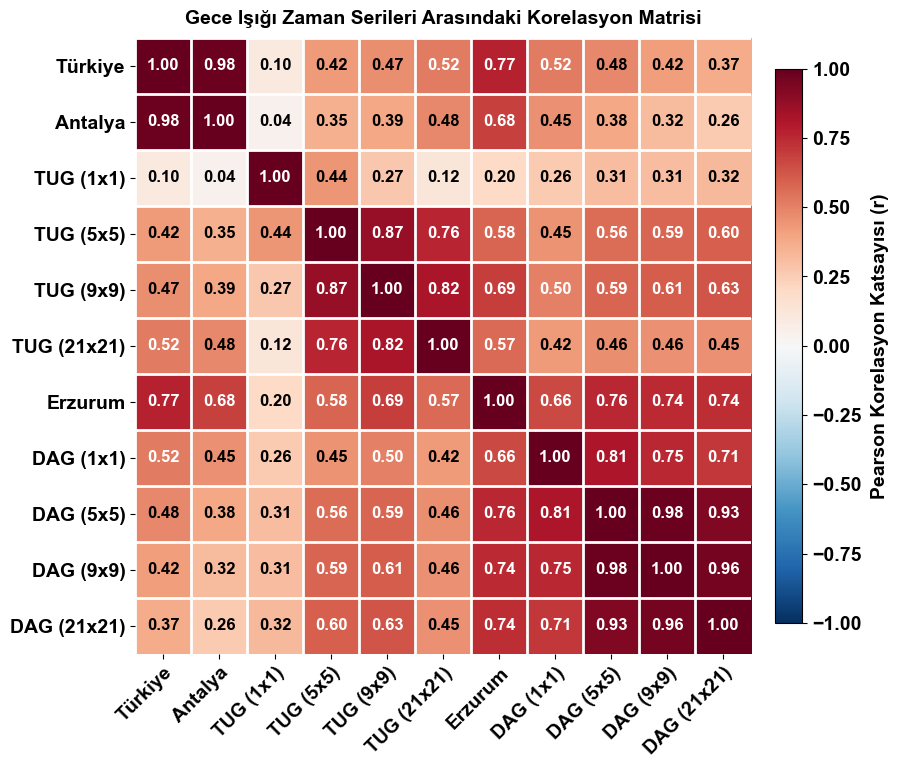

SONUC_RAPORU: ================================================================================
SONUC_RAPORU: 14 YILLIK (2012-2025) GECE IŞIKLARI PEARSEN KORELASYON ANALİZİ (AYLIK):
SONUC_RAPORU: --------------------------------------------------------------------------------
SONUC_RAPORU: --- TÜRKIYE KORELASYONLARI ---
SONUC_RAPORU: Türkiye <-> Antalya : r = 0.982496
SONUC_RAPORU: Türkiye <-> TUG (1x1) : r = 0.101332
SONUC_RAPORU: Türkiye <-> TUG (5x5) : r = 0.423966
SONUC_RAPORU: Türkiye <-> TUG (9x9) : r = 0.466242
SONUC_RAPORU: Türkiye <-> TUG (21x21) : r = 0.520472
SONUC_RAPORU: Türkiye <-> Erzurum : r = 0.772906
SONUC_RAPORU: Türkiye <-> DAG (1x1) : r = 0.522566
SONUC_RAPORU: Türkiye <-> DAG (5x5) : r = 0.478379
SONUC_RAPORU: Türkiye <-> DAG (9x9) : r = 0.419934
SONUC_RAPORU: Türkiye <-> DAG (21x21) : r = 0.373528
SONUC_RAPORU: --------------------------------------------------------------------------------
SONUC_RAPORU: --- ANTALYA KORELASYONLARI ---
SONUC_RAPORU: Antalya <-> Tür

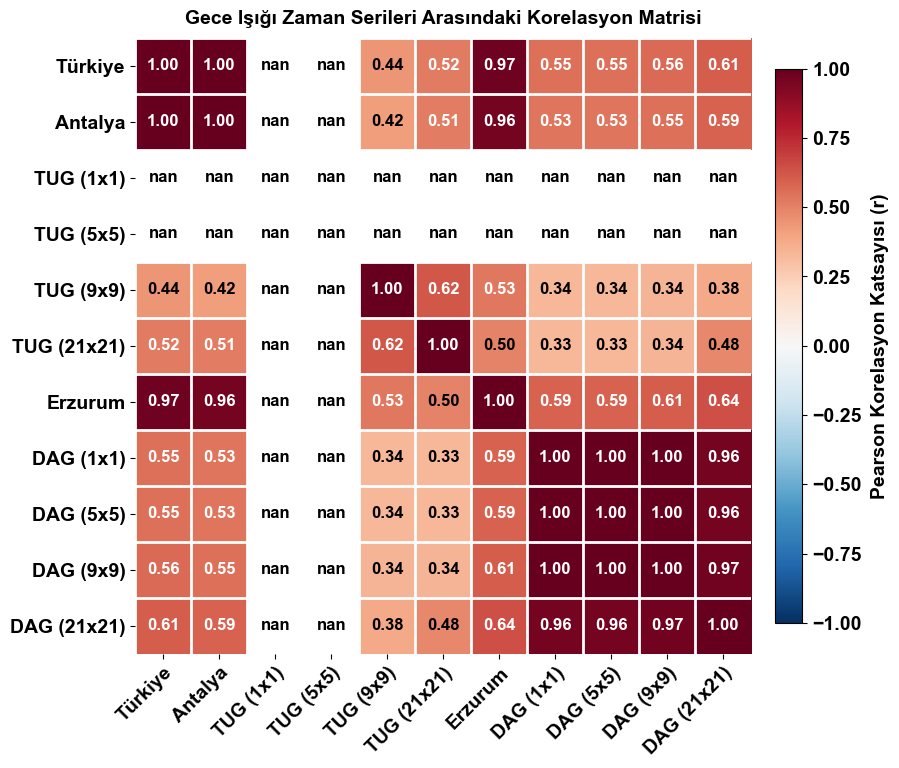

SONUC_RAPORU: ================================================================================
SONUC_RAPORU: 14 YILLIK (2012-2025) GECE IŞIKLARI PEARSEN KORELASYON ANALİZİ (YILLIK):
SONUC_RAPORU: --------------------------------------------------------------------------------
SONUC_RAPORU: --- TÜRKIYE KORELASYONLARI ---
SONUC_RAPORU: Türkiye <-> Antalya : r = 0.997579
SONUC_RAPORU: Türkiye <-> TUG (1x1) : r = nan
SONUC_RAPORU: Türkiye <-> TUG (5x5) : r = nan
SONUC_RAPORU: Türkiye <-> TUG (9x9) : r = 0.443076
SONUC_RAPORU: Türkiye <-> TUG (21x21) : r = 0.522301
SONUC_RAPORU: Türkiye <-> Erzurum : r = 0.973520
SONUC_RAPORU: Türkiye <-> DAG (1x1) : r = 0.548771
SONUC_RAPORU: Türkiye <-> DAG (5x5) : r = 0.548771
SONUC_RAPORU: Türkiye <-> DAG (9x9) : r = 0.564560
SONUC_RAPORU: Türkiye <-> DAG (21x21) : r = 0.608568
SONUC_RAPORU: --------------------------------------------------------------------------------
SONUC_RAPORU: --- ANTALYA KORELASYONLARI ---
SONUC_RAPORU: Antalya <-> Türkiye : r 

In [1]:

# Gerekli modülleri içe aktarıyoruz
import os
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import warnings
# Uyarıları kapatıyoruz
warnings.filterwarnings('ignore')

# ==========================================
# MATPLOTLIB RC PARAMETRELERİ
# ==========================================
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans', 'Helvetica', 'sans-serif']
plt.rcParams['mathtext.fontset'] = 'dejavusans'
plt.rcParams['mathtext.default'] = 'regular'
plt.rcParams['font.size'] = 14              # Genel varsayılan yazı boyutu
plt.rcParams['font.weight'] = 'bold'         # Genel kalın yazı
plt.rcParams['axes.labelsize'] = 14          # Eksen etiketleri boyutu
plt.rcParams['axes.titlesize'] = 14          # Alt grafik başlıkları boyutu
plt.rcParams['xtick.labelsize'] = 14         # X koordinat tick boyutları
plt.rcParams['ytick.labelsize'] = 14         # Y koordinat tick boyutları
plt.rcParams['legend.fontsize'] = 14         # Lejant yazı boyutu
plt.rcParams['figure.titlesize'] = 16        # Ana figür başlığı boyutu

def korelasyon_analizi_uret(veri_yolu, cikti_yolu, periyot_turu):
    """
    Belirtilen veri setini okur; Türkiye, Antalya, Erzurum, TUG ve DAG için
    NearNadir_SF katmanları arasındaki Pearson korelasyon matrisini hesaplar ve sıcaklık haritası çizer.
    """
    if not os.path.exists(veri_yolu):
        raise FileNotFoundError(f"Veri tabanı dosyası bulunamadı! Yolu kontrol edin: {veri_yolu}")

    # Veriyi okuma ve hazırlama
    df = pd.read_csv(veri_yolu, sep='\t', parse_dates=['Zaman (UTC)'])
    df.set_index('Zaman (UTC)', inplace=True)

    # Korelasyona sokulacak sütunların ve sade etiketlerinin tanımlanması
    analiz_sutunlari = {
        'Türkiye': 'Turkiye_NearNadir_SF_mean',
        'Antalya': 'Antalya_NearNadir_SF_mean',
        'TUG (1x1)': 'TUG_NearNadir_SF_1x1_mean',
        'TUG (5x5)': 'TUG_NearNadir_SF_5x5_mean',
        'TUG (9x9)': 'TUG_NearNadir_SF_9x9_mean',
        'TUG (21x21)': 'TUG_NearNadir_SF_21x21_mean',
        'Erzurum': 'Erzurum_NearNadir_SF_mean',
        'DAG (1x1)': 'DAG_NearNadir_SF_1x1_mean',
        'DAG (5x5)': 'DAG_NearNadir_SF_5x5_mean',
        'DAG (9x9)': 'DAG_NearNadir_SF_9x9_mean',
        'DAG (21x21)': 'DAG_NearNadir_SF_21x21_mean'
    }

    # Sadece analiz sütunlarını seçip boş (NaN) satırları eliyoruz
    df_subset = df[list(analiz_sutunlari.values())].dropna()
    df_subset.columns = list(analiz_sutunlari.keys())

    # Pearson Korelasyon Matrisinin Hesaplanması
    corr_matrix = df_subset.corr(method='pearson')
    
    # Grafik Tasarımı ve Çizim
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # RdBu_r (Red-Blue reversed) diverging renk haritası kullanıyoruz (1.0 Kırmızı, -1.0 Mavi)
    im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-1.0, vmax=1.0)

    # Renk çubuğunun (Colorbar) eklenmesi ve biçimlendirilmesi
    cbar = ax.figure.colorbar(im, ax=ax, shrink=0.9, pad=0.03)
    cbar.ax.set_ylabel('Pearson Korelasyon Katsayısı (r)', rotation=90, va="bottom", fontweight='bold', labelpad=20)

    # Eksen etiketlerinin ayarlanması
    ticks = np.arange(len(corr_matrix.columns))
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.set_xticklabels(corr_matrix.columns, rotation=45, ha="right", rotation_mode="anchor")
    ax.set_yticklabels(corr_matrix.columns)

    # Hücre içi sayısal korelasyon değerlerinin yazdırılması
    for i in range(len(corr_matrix.columns)):
        for j in range(len(corr_matrix.columns)):
            val = corr_matrix.iloc[i, j]
            # Okunabilirliği artırmak için metin rengini arka plana göre siyah veya beyaz yapıyoruz
            color = "white" if abs(val) > 0.5 else "black"
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", color=color, fontweight='bold', fontsize=12)

    # Çerçeve ve Grid çizgilerinin kapatılması (Sıcaklık haritası netliği için)
    ax.spines[:].set_visible(False)
    ax.set_xticks(ticks - 0.5, minor=True)
    ax.set_yticks(ticks - 0.5, minor=True)
    ax.grid(which="minor", color="w", linestyle='-', linewidth=2)
    ax.tick_params(which="minor", bottom=False, left=False)

    periyot_adi = "Aylık" if periyot_turu == "aylik" else "Yıllık"
    ax.set_title(f'Gece Işığı Zaman Serileri Arasındaki Korelasyon Matrisi', fontweight='bold', pad=10)

    # Kaydetme
    plt.savefig(cikti_yolu, dpi=500, bbox_inches='tight')
    plt.show()
    plt.close()

    # Sonuç Raporlama (Konsol Çıktıları)
    print('SONUC_RAPORU: ' + '='*80)
    print(f"SONUC_RAPORU: 14 YILLIK (2012-2025) GECE IŞIKLARI PEARSEN KORELASYON ANALİZİ ({periyot_adi.upper()}):")
    print('SONUC_RAPORU: ' + '-'*80)
    # Matris satırlarını sırayla konsola yazdırıyoruz
    for col in corr_matrix.columns:
        print(f"SONUC_RAPORU: --- {col.upper()} KORELASYONLARI ---")
        for index in corr_matrix.index:
            if col != index:
                print(f"SONUC_RAPORU: {col} <-> {index} : r = {corr_matrix.loc[index, col]:.6f}")
        print('SONUC_RAPORU: ' + '-'*80)
    print(f"SONUC_RAPORU: Korelasyon Matris Grafiği Başarıyla Kaydedildi  : {cikti_yolu}")
    print('SONUC_RAPORU: ' + '='*80)

# ==========================================
# ÇALIŞTIRMA BÖLÜMÜ
# ==========================================

# 1. Aylık Veriler için Korelasyon Matrisinin Üretilmesi (VNP46A3)
korelasyon_analizi_uret(
    veri_yolu='=cikti/tsa/=antalya_erzurum_turkiye_monthly_ntl.txt',
    cikti_yolu='=cikti/tsa/SONUC_RAPORU_NTL_TSA_05_gozlemevi_korelasyon_matrisi_aylik.png',
    periyot_turu='aylik'
)

# 2. Yıllık Veriler için Korelasyon Matrisinin Üretilmesi (VNP46A4)
korelasyon_analizi_uret(
    veri_yolu='=cikti/tsa/=antalya_erzurum_turkiye_annual_ntl.txt',
    cikti_yolu='=cikti/tsa/SONUC_RAPORU_NTL_TSA_05_gozlemevi_korelasyon_matrisi_yillik.png',
    periyot_turu='yillik'
)



## **5.8 Bölüm Özeti**


- Bu eğitim ve uygulama serisinde, uydu kaynaklı gece ışığı radyans verilerinin ön işlenmesi ve analitik olarak modellenmesi süreçleri adım adım ele alınmıştır. 14 yıllık (2012-2025) uzun dönemli veri tabanları üzerinden yürütülen çalışmalar;

  1. Ham HDF5 uydu görüntülerinin indirilmesi, coğrafi referanslandırılması ve Türkiye genelinde mozaiklenmesini,

  2. GADM il sınırları kullanılarak Antalya ve Erzurum çalışma alanlarının coğrafi olarak maskelenmesini,
 
  3. Gözlemevi (TUG ve DAG) yerleşkeleri özelinde noktasal (1×1) ve çevresel (3×3, 21×21 piksel vb.) çoklu tampon bölgelerden dikey radyans verilerinin çekilmesini,
 
  4. Kar örtüsünün yapay ışık kirliliğini artırma etkisinin uydunun dikey (NearNadir) ve eğik (OffNadir) bakış açılarına göre mevsimsel ve yıllık bazda nicelleştirilmesini,
 
  5. Parametrik (Doğrusal Regresyon) ve uç değerlere dayanıklı non-parametrik (Mann-Kendall Trend Testi ve Sen's Slope Tahmincisi) yöntemlerle 14 yıllık radyans ivmelerinin ve istatistiksel anlamlılıkların hesaplanmasını,
 
  6. Ve son olarak, kentsel yapay ışık havzaları ile gözlemevleri arasındaki mekânsal ayrışma düzeyleri korelasyon sıcaklık haritalarıyla tespit edilmiştir.

- Elde edilen sonuçlar, yüksek rakımlı gözlemevi yerleşkelerimizin gökyüzü kalitesinin korunmasında hem yerel ışık kontrollerinin hem de bölgesel ölçekte spektral (mavi ışık kısıtlaması) ve mekânsal (imar sınırlamaları) koruma bantlarının hayati öneme sahip olduğunu doğrulamaktadır.

- Bu notebook serisinin, karanlık gökyüzü koruma alanlarının izlenmesi ve aydınlatma politikalarının geliştirilmesi süreçlerinde araştırmacılar ve uygulayıcılar için faydalı bir rehber olmasını ümit ederiz.



## **Yapay Zeka Kullanım Beyanı**

- Bu çalışmanın Python kodlarının geliştirilmesi, veri analiz algoritmalarının optimizasyonu, İngilizce-Türkçe akademik çeviriler ve raporlama süreçlerinde yapay zeka asistanından (Google Gemini) teknik ve dilsel destek alınmıştır. Çalışmanın bilimsel doğruluğu, veri bütünlüğü ve nihai raporlama sorumluluğu tamamen araştırmacılara aittir.
